<a href="https://colab.research.google.com/github/a00843399PACG/MCCThesisAD2026/blob/main/EDA_KP_Generators_Java_vs_Python_corrected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Equivalence and characterization of an evolutionary 0/1 Knapsack instance generator

Author: Paola Azeneth Castillo Gutierrez. Repository: `a00843399PACG/MCCThesisAD2026`.

## 0/1 Knapsack Problem

An instance is $I=(n,c,\{(w_j,p_j)\}_{j=1}^n)$ with $w_j,p_j,c\in\mathbb{N}$. The problem is

$$z^\*(I)=\max_{x\in\{0,1\}^n}\ \sum_{j=1}^n p_j\,x_j\quad\text{s.t.}\quad \sum_{j=1}^n w_j\,x_j\le c .$$

A configuration is $\theta=(n,c,W_{\max},P_{\max})$. Item coefficients are encoded on $b_w=\lceil\log_2 W_{\max}\rceil$ and $b_p=\lceil\log_2 P_{\max}\rceil$ bits, so the chromosome length is $L=n(b_w+b_p)$.

## Objects compared

Two implementations of the evolutionary generator of Plata-Gonzalez et al. (2019) are studied: a reference in Java and its Python translation. Let $G^{\mathrm{J}}_\theta(s)$ and $G^{\mathrm{P}}_\theta(s)$ be the instances produced from seed $s$ under configuration $\theta$.

**Proposition (implementation equivalence).** For every configuration $\theta$ and seed $s$, $G^{\mathrm{J}}_\theta(s)=G^{\mathrm{P}}_\theta(s)$ as byte strings. The translation reimplements the 48-bit linear congruential generator of `java.util.Random`, so both pseudo-random streams coincide and the decoded instances coincide. Part A tests this proposition empirically.

## Structure

Part A validates the equivalence and performs the exploratory analysis of the generated instances. Part B characterizes the generator as an object of study through the verifications R1, R2 and E1 to E10. Part C executes Phase I of those verifications on the $6{,}400$-instance dataset of the thesis. Part D examines reachability of the Pisinger correlation classes. Part E is the full inferential EDA of the feature space on the dataset. Part F computes solver hardness at scale ($\eta_{DP}$, $\eta_{LP}$, $\eta_{BB}$) with effect sizes and confidence intervals. Part G assembles the support boundary (Table 2). Part H is the Phase II campaign over the extended grid.

The evaluation budget of `KP.generate` is fixed at $10^5$ fitness evaluations per instance; wall-clock cost is approximately $2$ s per instance in Java and $30$ s in Python.


## 0. Configuration

The total number of instances per generator is
$N_{\text{type}}\cdot|\mathcal{T}|$, where $\mathcal{T}$ is the set of instance
types. Expected Python wall-clock time is approximately
$30\,\text{s}\times N_{\text{type}}\cdot|\mathcal{T}|$.


In [ ]:
from pathlib import Path

# --- Repository ---
REPO_URL  = "https://github.com/a00843399PACG/MCCThesisAD2026.git"
BRANCH    = "main"
REPO_DIR  = Path("MCCThesisAD2026")
JAVA_DIR  = REPO_DIR / "EvolutionaryGenerator_v2.1_Java"
PY_DIR    = REPO_DIR / "EvolutionaryGenerator_v2.1_Python"

# --- Sampling ---
SEED        = 12345   # same seed for both generators (guarantees identical instances)
N_PER_TYPE  = 3       # instances per type and per generator

# 4 EASY types = the thesis 4-heuristic portfolio (DEF, MAXP, MAXPW, MINW)
TYPE_TO_HEURISTIC = {
    "DEFAULT_EASY":           "DEF",
    "MAX_PROFIT_EASY":        "MAXP",
    "MAX_PROFIT_WEIGHT_EASY": "MAXPW",
    "MIN_WEIGHT_EASY":        "MINW",
}
INSTANCE_TYPES = list(TYPE_TO_HEURISTIC.keys())

# --- Generator parameters (the generator's own defaults) ---
ID              = "KP"
NB_ITEMS        = 10
CAPACITY        = 20
MAX_WEIGHT      = 20
MAX_PROFIT      = 50
POPULATION_SIZE = 20
CROSSOVER_RATE  = 1.0
MUTATION_RATE   = 0.1
TOURNAMENT_SIZE = 3

# --- Output folders ---
OUT_JAVA = Path("instances_java")
OUT_PY   = Path("instances_python")

_total = N_PER_TYPE * len(INSTANCE_TYPES)
print(f"Instances per generator: {_total}  ({N_PER_TYPE} x {len(INSTANCE_TYPES)} types)")
print(f"Estimated Python time:  ~{_total*30/60:.1f} min   |   Java: ~{_total*2/60:.1f} min")

# Hygiene (E.11): the GA budget is counted per fitness evaluation, so an odd population
# silently expands to mu+1 and overshoots it. Keep population sizes even, record seeds per
# configuration, and parallelize at process level (the encoding is static shared state, so
# two configurations in one process would race on it).
assert POPULATION_SIZE % 2 == 0, "population size must be even (odd -> mu+1 overshoots the budget)"


Instances per generator: 12  (3 x 4 types)
Estimated Python time:  ~6.0 min   |   Java: ~0.4 min


## 1. Clone the repository

In [ ]:
import shutil, subprocess, sys

if REPO_DIR.exists():
    print(f"'{REPO_DIR}' already exists; reusing it. (Delete the folder to clone again.)")
else:
    subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(REPO_DIR)],
        check=True,
    )

assert JAVA_DIR.exists(), f"Not found: {JAVA_DIR}"
assert PY_DIR.exists(),   f"Not found: {PY_DIR}"
print("\nRepository contents:")
for p in sorted(REPO_DIR.iterdir()):
    print("  ", p.name)

'MCCThesisAD2026' already exists; reusing it. (Delete the folder to clone again.)

Repository contents:
   .git
   .gitignore
   EvolutionaryGenerator_v2.1_Formalization.pdf
   EvolutionaryGenerator_v2.1_Java
   EvolutionaryGenerator_v2.1_Python
   README.md
   license


## 2. Compilation of the Java generator

The Java sources are three NetBeans projects (`Generator`, `MetaH`, `Utils`) with
no external dependencies; all sources are compiled together. The original project
declares `main.class=Run`, but `Run.java` is absent from the sources, so a driver
is added that calls `KP.generate(...)` with the public signature exposed by the
Java version. The locale is fixed to `Locale.US` so that the decimal separator is
`.`, which is a necessary condition for byte-level equality with the Python
output.


In [ ]:
import os, subprocess

# 2.1 Ensure a JDK
def _has(cmd):
    from shutil import which
    return which(cmd) is not None

if not (_has("javac") and _has("java")):
    print("Installing default-jdk (may take 1-2 min)...")
    subprocess.run(["apt-get", "-qq", "install", "-y", "default-jdk"], check=True)

print(subprocess.run(["javac", "-version"], capture_output=True, text=True).stderr.strip())

# 2.2 Compile every Java source
BIN = Path("java_bin")
if BIN.exists():
    shutil.rmtree(BIN)
BIN.mkdir()

java_files = sorted(str(p) for p in JAVA_DIR.rglob("*.java"))
print(f".java files to compile: {len(java_files)}")
argfile = Path("java_sources.txt")
argfile.write_text("\n".join(java_files), encoding="utf-8")

r = subprocess.run(
    ["javac", "-encoding", "UTF-8", "-d", str(BIN), f"@{argfile}"],
    capture_output=True, text=True,
)
if r.returncode != 0:
    print(r.stdout); print(r.stderr)
    raise RuntimeError("Java generator compilation failed")
print("Generator sources compiled.")

# 2.3 Write and compile the driver Run.java
RUN_JAVA = r"""
import java.io.File;
import java.util.Locale;
import mx.tec.hermes.problems.kp.KP;
import mx.tec.hermes.problems.kp.generator.KPEvaluator;

public class Run {
    public static void main(String[] args) {
        Locale.setDefault(Locale.US);
        KPEvaluator.InstanceType type = KPEvaluator.InstanceType.valueOf(args[0]);
        int nbInstances   = Integer.parseInt(args[1]);
        String id         = args[2];
        String path       = args[3];
        int nbItems       = Integer.parseInt(args[4]);
        int capacity      = Integer.parseInt(args[5]);
        int maxWeight     = Integer.parseInt(args[6]);
        int maxProfit     = Integer.parseInt(args[7]);
        int populationSize= Integer.parseInt(args[8]);
        double crossover  = Double.parseDouble(args[9]);
        double mutation   = Double.parseDouble(args[10]);
        int tournament    = Integer.parseInt(args[11]);
        long seed         = Long.parseLong(args[12]);
        if (!path.endsWith("/")) path = path + "/";
        new File(path).mkdirs();
        KP.generate(type, nbInstances, id, path, nbItems, capacity, maxWeight,
                    maxProfit, populationSize, crossover, mutation, tournament, seed);
    }
}
"""
Path("Run.java").write_text(RUN_JAVA, encoding="utf-8")
r = subprocess.run(
    ["javac", "-cp", str(BIN), "-d", str(BIN), "Run.java"],
    capture_output=True, text=True,
)
if r.returncode != 0:
    print(r.stdout); print(r.stderr)
    raise RuntimeError("Driver Run.java compilation failed")
print("Driver Run.java compiled.")


.java files to compile: 28
Generator sources compiled.
Driver Run.java compiled.


## 3. Generation with the Java implementation

One output directory per instance type. The generator trace on standard output is
discarded.


In [ ]:
import time

def run_java(instance_type, out_dir, seed):
    out = (Path(out_dir) / instance_type).resolve()
    out.mkdir(parents=True, exist_ok=True)
    cmd = [
        "java", "-Duser.language=en", "-Duser.country=US",
        "-cp", str(BIN.resolve()), "Run",
        instance_type, str(N_PER_TYPE), ID, str(out) + "/",
        str(NB_ITEMS), str(CAPACITY), str(MAX_WEIGHT), str(MAX_PROFIT),
        str(POPULATION_SIZE), str(CROSSOVER_RATE), str(MUTATION_RATE),
        str(TOURNAMENT_SIZE), str(seed),
    ]
    r = subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, text=True)
    if r.returncode != 0:
        print(r.stderr); raise RuntimeError(f"Java failed on {instance_type}")

if OUT_JAVA.exists():
    shutil.rmtree(OUT_JAVA)

t0 = time.time()
for t in INSTANCE_TYPES:
    ti = time.time()
    run_java(t, OUT_JAVA, SEED)
    n = len(list((OUT_JAVA / t).glob("*.kp")))
    print(f"  [Java]   {t:<24} {n} instances  ({time.time()-ti:.1f}s)")
print(f"Java done in {time.time()-t0:.1f}s")

  [Java]   DEFAULT_EASY             3 instances  (14.4s)
  [Java]   MAX_PROFIT_EASY          3 instances  (10.9s)
  [Java]   MAX_PROFIT_WEIGHT_EASY   3 instances  (8.2s)
  [Java]   MIN_WEIGHT_EASY          3 instances  (8.3s)
Java done in 41.8s


## 4. Generation with the Python implementation

Identical instance types, seed and parameters. Wall-clock cost is approximately
$30$ s per instance.


In [ ]:
def run_python(instance_type, out_dir, seed):
    out = (Path(out_dir) / instance_type).resolve()
    out.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable, "main.py", "generate",
        "--type", instance_type, "--nb-instances", str(N_PER_TYPE),
        "--id", ID, "--path", str(out) + "/",
        "--nb-items", str(NB_ITEMS), "--capacity", str(CAPACITY),
        "--max-weight", str(MAX_WEIGHT), "--max-profit", str(MAX_PROFIT),
        "--population-size", str(POPULATION_SIZE),
        "--crossover-rate", str(CROSSOVER_RATE),
        "--mutation-rate", str(MUTATION_RATE),
        "--tournament-size", str(TOURNAMENT_SIZE),
        "--seed", str(seed),
    ]
    # main.py imports 'hermes'/'metah' relatively: run it from PY_DIR.
    r = subprocess.run(cmd, cwd=str(PY_DIR), stdout=subprocess.DEVNULL,
                       stderr=subprocess.PIPE, text=True)
    if r.returncode != 0:
        print(r.stderr); raise RuntimeError(f"Python failed on {instance_type}")

if OUT_PY.exists():
    shutil.rmtree(OUT_PY)

t0 = time.time()
for t in INSTANCE_TYPES:
    ti = time.time()
    run_python(t, OUT_PY, SEED)
    n = len(list((OUT_PY / t).glob("*.kp")))
    print(f"  [Python] {t:<24} {n} instances  ({time.time()-ti:.1f}s)")
print(f"Python done in {time.time()-t0:.1f}s")

  [Python] DEFAULT_EASY             3 instances  (138.5s)
  [Python] MAX_PROFIT_EASY          3 instances  (139.5s)
  [Python] MAX_PROFIT_WEIGHT_EASY   3 instances  (148.4s)
  [Python] MIN_WEIGHT_EASY          3 instances  (138.9s)
Python done in 565.3s


## 5. Equivalence validation (byte level)

Let $B^{\mathrm{J}}_{\theta,s}$ and $B^{\mathrm{P}}_{\theta,s}$ be the byte
contents of the `.kp` files produced under configuration $\theta$ and seed $s$.
The equivalence proposition asserts
$B^{\mathrm{J}}_{\theta,s}=B^{\mathrm{P}}_{\theta,s}$ for all $\theta,s$. Files are
matched by name and compared byte for byte; a single differing byte falsifies the
proposition for that pair.


In [ ]:
import pandas as pd

rows = []
first_diff = None
for t in INSTANCE_TYPES:
    jdir, pdir = OUT_JAVA / t, OUT_PY / t
    jfiles = sorted(p.name for p in jdir.glob("*.kp"))
    pfiles = sorted(p.name for p in pdir.glob("*.kp"))
    common = sorted(set(jfiles) & set(pfiles))
    matched = 0
    for name in common:
        jb = (jdir / name).read_bytes()
        pb = (pdir / name).read_bytes()
        if jb == pb:
            matched += 1
        elif first_diff is None:
            first_diff = (t, name, jb, pb)
    rows.append({"instance_type": t, "java_files": len(jfiles), "python_files": len(pfiles),
                 "compared": len(common), "identical": matched,
                 "all_equal": (matched == len(common) == len(jfiles) == len(pfiles))})

eq_df = pd.DataFrame(rows)
display(eq_df)

all_equal = bool(eq_df["all_equal"].all())
if all_equal:
    print("\nEQUIVALENCE CONFIRMED: every .kp file is byte-for-byte identical.")
else:
    print("\nDIFFERENCES FOUND.")
    if first_diff:
        t, name, jb, pb = first_diff
        print(f"First differing file: {t}/{name}")
        jl = jb.decode(errors="replace").splitlines()
        pl = pb.decode(errors="replace").splitlines()
        for i in range(max(len(jl), len(pl))):
            a = jl[i] if i < len(jl) else "<empty>"
            b = pl[i] if i < len(pl) else "<empty>"
            if a != b:
                print(f"  line {i}: Java='{a}'  Python='{b}'")

,instance_type,java_files,python_files,compared,identical,all_equal
0,DEFAULT_EASY,3,3,3,3,True
1,MAX_PROFIT_EASY,3,3,3,3,True
2,MAX_PROFIT_WEIGHT_EASY,3,3,3,3,True
3,MIN_WEIGHT_EASY,3,3,3,3,True



EQUIVALENCE CONFIRMED: every .kp file is byte-for-byte identical.


## 6. Feature map

Each `.kp` file has a header `n, capacity` followed by `n` lines `weight, profit`.
Let $\hat w_j=w_j/\max_k w_k$ and $\hat p_j=p_j/\max_k p_k$. The feature map of
Plata-Gonzalez et al. (2019), Definition 3 in [3], is $\Phi:\mathcal{I}\to[0,1]^7$,

$$\Phi(I)=\Big(\ \overline{\hat w},\ \operatorname{med}\hat w,\ \operatorname{sd}\hat w,\ \overline{\hat p},\ \operatorname{med}\hat p,\ \operatorname{sd}\hat p,\ \tfrac12\big(\rho(w,p)+1\big)\ \Big),$$

where $\overline{(\cdot)}$ is the mean, $\operatorname{med}$ the median,
$\operatorname{sd}$ the sample standard deviation (`ddof=1`), and $\rho(w,p)$ the
Pearson correlation. The seventh component rescales $\rho\in[-1,1]$ to $[0,1]$.
The raw correlation $\rho(w,p)$ and the capacity ratio $\alpha(I)=c/\sum_j w_j$
are retained as auxiliary descriptors.


In [ ]:
import numpy as np

def parse_kp(path):
    text = Path(path).read_text()
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    n_items = int(lines[0].split(",")[0])
    capacity = int(float(lines[0].split(",")[1]))
    w = np.empty(n_items); p = np.empty(n_items)
    for j in range(n_items):
        a, b = lines[1 + j].split(",")
        w[j] = float(a); p[j] = float(b)
    return n_items, capacity, w, p

def compute_features(n_items, capacity, w, p):
    wmax, pmax = w.max(), p.max()
    if n_items >= 2 and np.std(w) > 0 and np.std(p) > 0:
        r = float(np.corrcoef(w, p)[0, 1])
    else:
        r = 0.0
    return {
        "n_items": n_items, "capacity": capacity,
        "w_mean": w.mean()/wmax, "w_median": np.median(w)/wmax, "w_std": w.std(ddof=1)/wmax,
        "p_mean": p.mean()/pmax, "p_median": np.median(p)/pmax, "p_std": p.std(ddof=1)/pmax,
        "wp_corr_raw": r, "wp_corr": r/2 + 0.5,
        "capacity_ratio": capacity/w.sum(),
    }

FEATURES = ["w_mean","w_median","w_std","p_mean","p_median","p_std","wp_corr","wp_corr_raw","capacity_ratio"]

def build_df(out_dir, generator):
    recs = []
    for t in INSTANCE_TYPES:
        for f in sorted((Path(out_dir)/t).glob("*.kp")):
            n, c, w, p = parse_kp(f)
            row = {"generator": generator, "instance_type": t,
                   "dominant_heuristic": TYPE_TO_HEURISTIC[t], "filename": f.name}
            row.update(compute_features(n, c, w, p))
            recs.append(row)
    return pd.DataFrame(recs)

df_java = build_df(OUT_JAVA, "Java")
df_py   = build_df(OUT_PY,   "Python")
df_all  = pd.concat([df_java, df_py], ignore_index=True)
print(f"Java:   {df_java.shape[0]} instances")
print(f"Python: {df_py.shape[0]} instances")
df_all.head(len(INSTANCE_TYPES)*2)


Java:   12 instances
Python: 12 instances


,generator,instance_type,dominant_heuristic,filename,n_items,capacity,w_mean,w_median,w_std,p_mean,p_median,p_std,wp_corr_raw,wp_corr,capacity_ratio
0,Java,DEFAULT_EASY,DEF,KP_20_50_10_000.kp,10,20,0.546667,0.583333,0.359423,0.544444,0.555556,0.315430,-0.257820,0.371090,0.121951
1,Java,DEFAULT_EASY,DEF,KP_20_50_10_001.kp,10,20,0.583871,0.596774,0.314394,0.625806,0.661290,0.314118,-0.030323,0.484839,0.110497
2,Java,DEFAULT_EASY,DEF,KP_20_50_10_002.kp,10,20,0.648387,0.709677,0.334701,0.790323,0.895161,0.245552,0.446660,0.723330,0.099502
3,Java,MAX_PROFIT_EASY,MAXP,KP_20_50_10_000.kp,10,20,0.523077,0.576923,0.325449,0.501563,0.429688,0.320763,0.157608,0.578804,0.147059
4,Java,MAX_PROFIT_EASY,MAXP,KP_20_50_10_001.kp,10,20,0.643750,0.718750,0.349913,0.438095,0.436508,0.272289,0.100306,0.550153,0.097087
5,Java,MAX_PROFIT_EASY,MAXP,KP_20_50_10_002.kp,10,20,0.581250,0.640625,0.308023,0.590323,0.572581,0.310453,-0.074143,0.462929,0.107527
6,Java,MAX_PROFIT_WEIGHT_EASY,MAXPW,KP_20_50_10_000.kp,10,20,0.373333,0.283333,0.272528,0.550000,0.453125,0.375275,0.061450,0.530725,0.178571
7,Java,MAX_PROFIT_WEIGHT_EASY,MAXPW,KP_20_50_10_001.kp,10,20,0.470000,0.366667,0.329403,0.567797,0.669492,0.399835,0.091274,0.545637,0.141844


### 6.1 Validation of the feature map

The worked example of Plata-Gonzalez et al. (2019) has weights $(2,2,3,4)$ and
profits $(10,5,6,15)$, with reference values
$(0.69,0.63,0.24,0.60,0.53,0.30,0.69)$. The implementation is checked against
these values.


In [ ]:
_f = compute_features(4, 10, np.array([2.,2.,3.,4.]), np.array([10.,5.,6.,15.]))
_exp = {"w_mean":0.688,"w_median":0.625,"w_std":0.239,"p_mean":0.600,
        "p_median":0.533,"p_std":0.303,"wp_corr_raw":0.689,"wp_corr":0.845}
_ok = all(abs(_f[k]-v) < 0.01 for k, v in _exp.items())
for k, v in _exp.items():
    print(f"  {k:<12} computed={_f[k]:.3f}  expected={v:.3f}  {'OK' if abs(_f[k]-v)<0.01 else 'FAIL'}")
print("\nExtractor validated." if _ok else "\nEXTRACTOR ERROR.")
assert _ok

  w_mean       computed=0.688  expected=0.688  OK
  w_median     computed=0.625  expected=0.625  OK
  w_std        computed=0.239  expected=0.239  OK
  p_mean       computed=0.600  expected=0.600  OK
  p_median     computed=0.533  expected=0.533  OK
  p_std        computed=0.303  expected=0.303  OK
  wp_corr_raw  computed=0.689  expected=0.689  OK
  wp_corr      computed=0.845  expected=0.845  OK

Extractor validated.


## 7. Descriptive statistics

Per-generator summary of the seven features. Under the equivalence proposition the
two summaries coincide exactly.


In [ ]:
feat7 = ["w_mean","w_median","w_std","p_mean","p_median","p_std","wp_corr"]
print("=== Java ===")
display(df_java[feat7].describe().round(4))
print("=== Python ===")
display(df_py[feat7].describe().round(4))

=== Java ===


,w_mean,w_median,w_std,p_mean,p_median,p_std,wp_corr
count,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000
mean,0.5566,0.5762,0.3063,0.5937,0.6119,0.3155,0.4474
std,0.0886,0.1503,0.0448,0.0952,0.1348,0.0541,0.1735
min,0.3733,0.2833,0.2353,0.4381,0.4297,0.2238,0.1236
25%,0.5028,0.5070,0.2690,0.5439,0.5299,0.2955,0.3525
50%,0.5640,0.5901,0.3199,0.5791,0.6300,0.3124,0.5016
75%,0.6449,0.7114,0.3385,0.6295,0.6701,0.3344,0.5468
max,0.6621,0.7586,0.3594,0.7903,0.8952,0.3998,0.7233


=== Python ===


,w_mean,w_median,w_std,p_mean,p_median,p_std,wp_corr
count,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000
mean,0.5566,0.5762,0.3063,0.5937,0.6119,0.3155,0.4474
std,0.0886,0.1503,0.0448,0.0952,0.1348,0.0541,0.1735
min,0.3733,0.2833,0.2353,0.4381,0.4297,0.2238,0.1236
25%,0.5028,0.5070,0.2690,0.5439,0.5299,0.2955,0.3525
50%,0.5640,0.5901,0.3199,0.5791,0.6300,0.3124,0.5016
75%,0.6449,0.7114,0.3385,0.6295,0.6701,0.3344,0.5468
max,0.6621,0.7586,0.3594,0.7903,0.8952,0.3998,0.7233


## 8. Feature-level comparison

Two statistics per feature. First, the maximum absolute difference between matched
instances, $\max_I|\Phi_k(I^{\mathrm{J}})-\Phi_k(I^{\mathrm{P}})|$. Second, the
two-sample Kolmogorov-Smirnov statistic
$D_{m,n}=\sup_x|F_m(x)-G_n(x)|$, where $F_m,G_n$ are the empirical CDFs of feature
$k$ for the Java and Python samples. Under the equivalence proposition both
generators yield the same instances, so $D_{m,n}=0$ and the p-value is $1$.


In [ ]:
from scipy.stats import ks_2samp

merged = df_java.merge(df_py, on=["instance_type","filename"], suffixes=("_java","_py"))
rows = []
for f in feat7 + ["wp_corr_raw","capacity_ratio"]:
    max_abs = (merged[f+"_java"] - merged[f+"_py"]).abs().max()
    ks = ks_2samp(df_java[f], df_py[f])
    rows.append({"feature": f, "max_abs_diff": max_abs,
                 "KS_stat": ks.statistic, "KS_pvalue": ks.pvalue})
cmp_df = pd.DataFrame(rows)
display(cmp_df.round(6))

feat_equal = bool((cmp_df["max_abs_diff"] < 1e-9).all())
print("\nFeatures identical between Java and Python." if feat_equal
      else "\nFeature-level differences found (see section 5).")

,feature,max_abs_diff,KS_stat,KS_pvalue
0,w_mean,0.0,0.0,1.0
1,w_median,0.0,0.0,1.0
2,w_std,0.0,0.0,1.0
3,p_mean,0.0,0.0,1.0
4,p_median,0.0,0.0,1.0
5,p_std,0.0,0.0,1.0
6,wp_corr,0.0,0.0,1.0
7,wp_corr_raw,0.0,0.0,1.0
8,capacity_ratio,0.0,0.0,1.0



Features identical between Java and Python.


## 9. Visualizations

Overlay of the Java and Python feature distributions (coincident under the
equivalence proposition) and the conditional distributions of each feature given
the dominant heuristic.


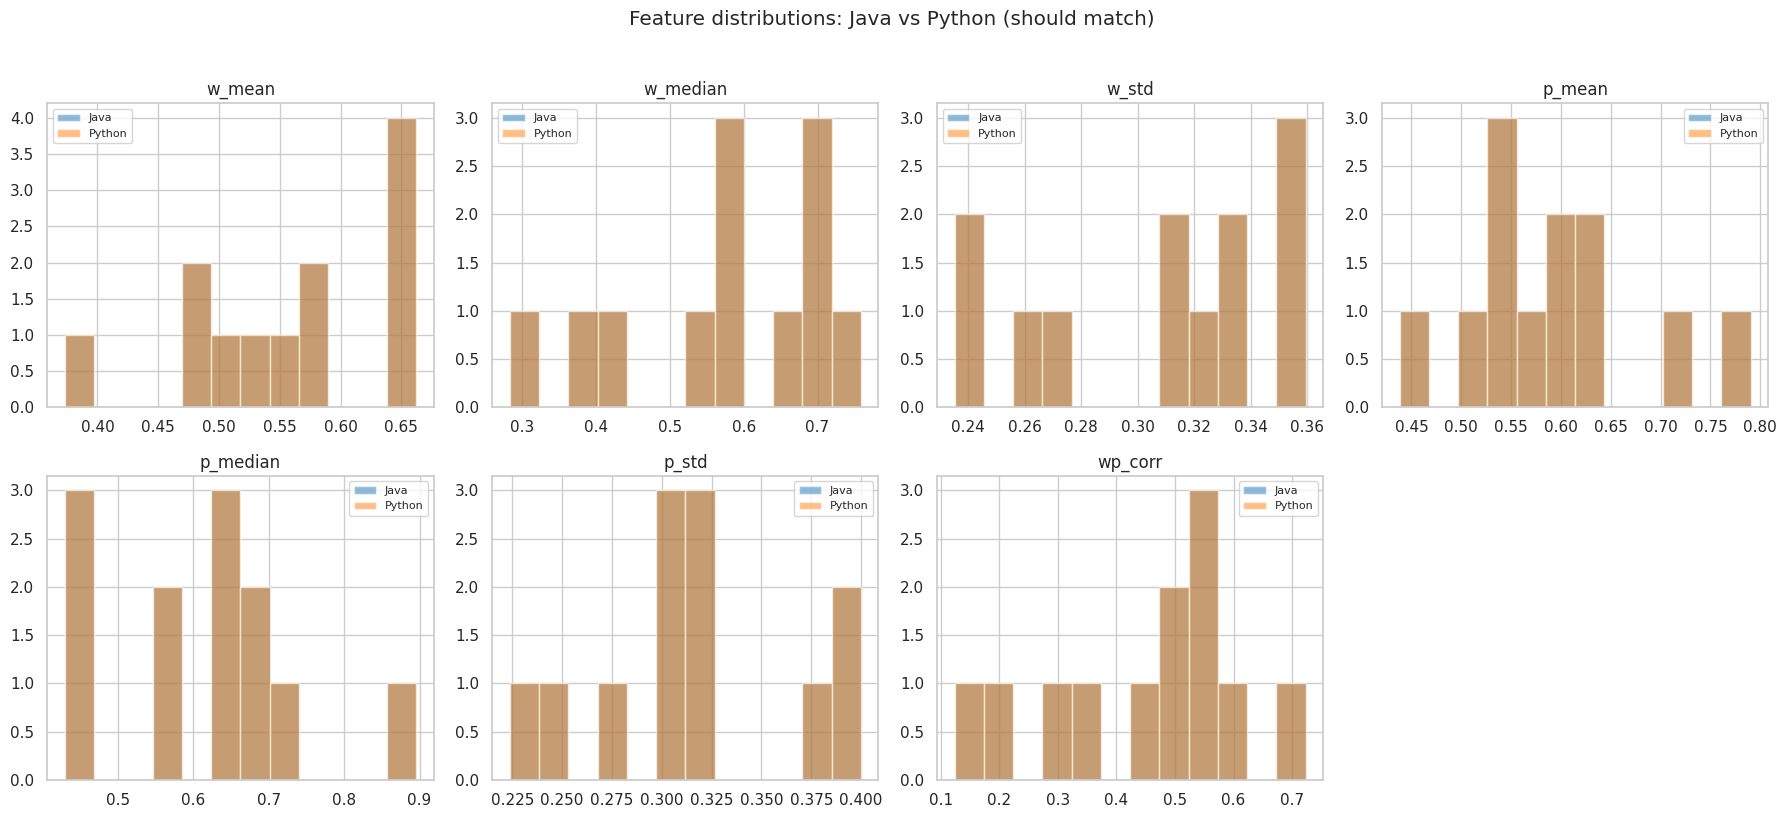

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# 9.1 Java vs Python overlay per feature
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, f in zip(axes.ravel(), feat7):
    for gen, color in [("Java", "#1f77b4"), ("Python", "#ff7f0e")]:
        sub = df_all[df_all.generator == gen][f]
        ax.hist(sub, bins=12, alpha=0.5, label=gen, color=color)
    ax.set_title(f); ax.legend(fontsize=8)
axes.ravel()[-1].axis("off")
fig.suptitle("Feature distributions: Java vs Python (should match)", y=1.02)
plt.tight_layout(); plt.show()

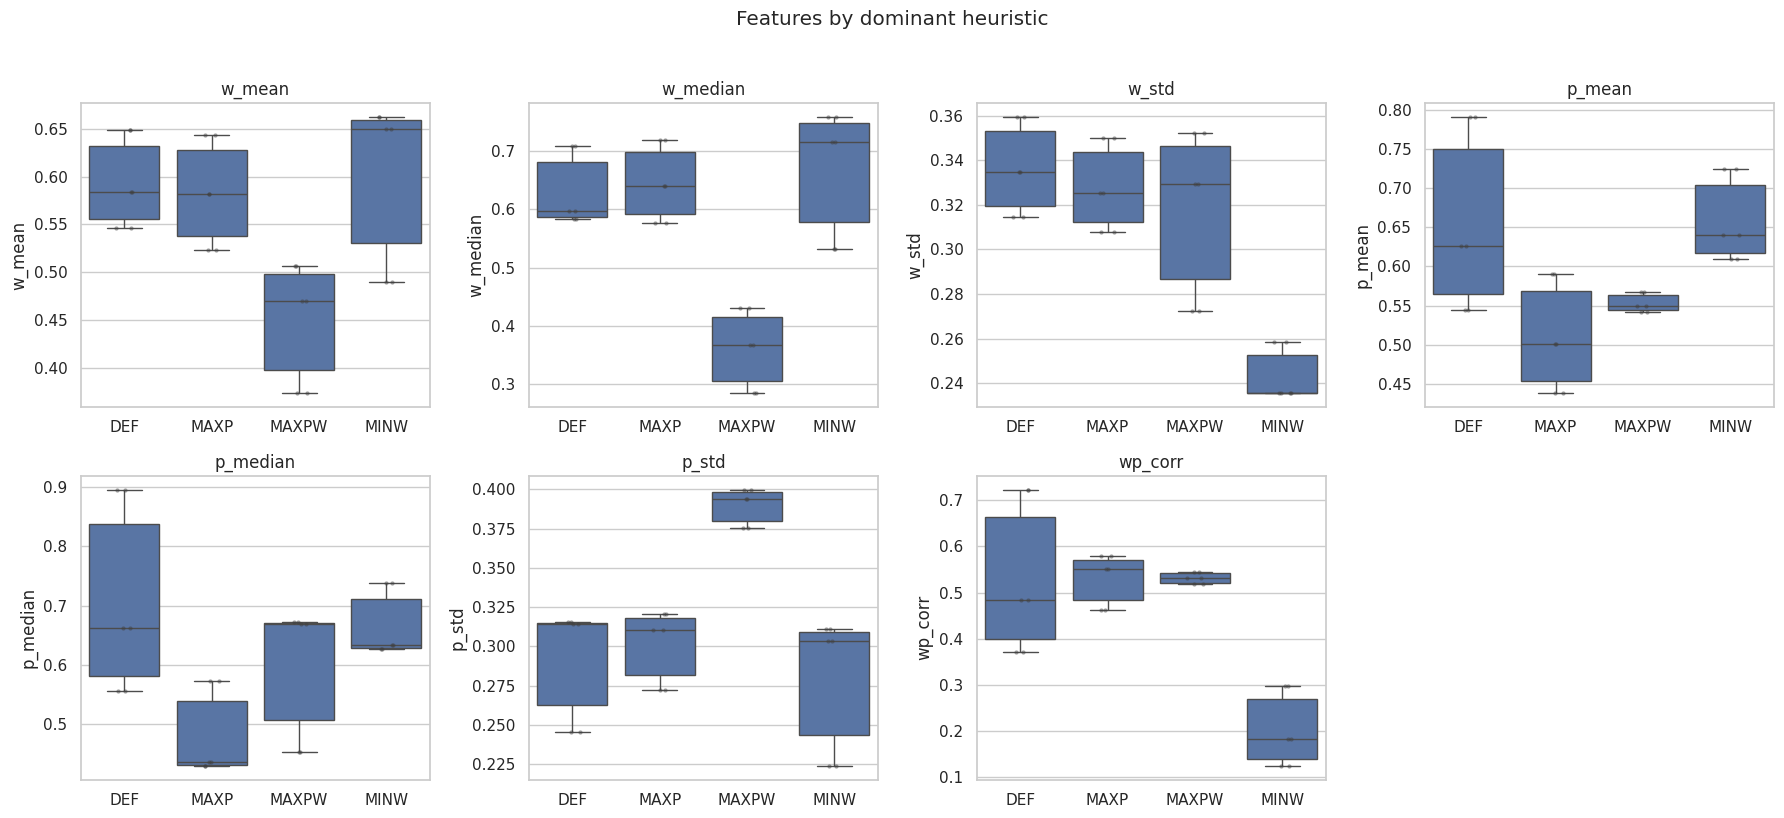

In [ ]:
# 9.2 Features by dominant heuristic (using the combined set)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
order = ["DEF","MAXP","MAXPW","MINW"]
for ax, f in zip(axes.ravel(), feat7):
    sns.boxplot(data=df_all, x="dominant_heuristic", y=f, order=order, ax=ax)
    sns.stripplot(data=df_all, x="dominant_heuristic", y=f, order=order,
                  ax=ax, color=".25", size=3, alpha=.5)
    ax.set_title(f); ax.set_xlabel("")
axes.ravel()[-1].axis("off")
fig.suptitle("Features by dominant heuristic", y=1.02)
plt.tight_layout(); plt.show()

> Note: the PCA below uses a global `StandardScaler` and is for visualization only.
> Scale-invariance (Theorem 2) and the nesting result require per-instance normalization;
> read the invariance from R2, not from this global-scaled projection.


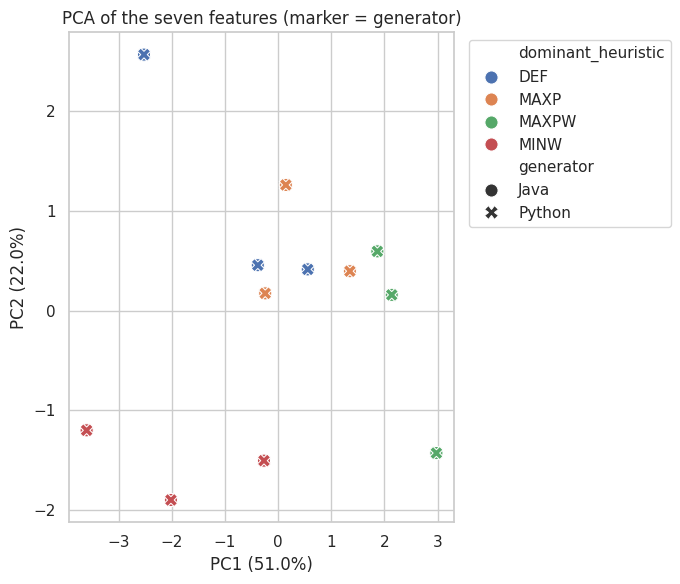

In [ ]:
# 9.3 2D PCA of the seven features, colored by dominant heuristic
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_all[feat7].values
if X.shape[0] >= 3:
    Xs = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2).fit(Xs)
    Z = pca.transform(Xs)
    df_all["_pc1"], df_all["_pc2"] = Z[:,0], Z[:,1]
    plt.figure(figsize=(7,6))
    sns.scatterplot(data=df_all, x="_pc1", y="_pc2", hue="dominant_heuristic",
                    style="generator", s=90)
    ev = pca.explained_variance_ratio_
    plt.xlabel(f"PC1 ({ev[0]*100:.1f}%)"); plt.ylabel(f"PC2 ({ev[1]*100:.1f}%)")
    plt.title("PCA of the seven features (marker = generator)")
    plt.legend(bbox_to_anchor=(1.02,1), loc="upper left"); plt.tight_layout(); plt.show()
else:
    print("Too few instances for PCA; raise N_PER_TYPE.")


## 10. Separability by heuristic class

For each feature, the Kruskal-Wallis test evaluates $H_0$: the four heuristic
classes share a common median. With $N$ pooled observations, group sizes $n_i$ and
mean ranks $\bar R_i$,

$$H=\frac{12}{N(N+1)}\sum_{i=1}^{4} n_i\Big(\bar R_i-\tfrac{N+1}{2}\Big)^2 .$$

Statistical power is bounded by the sample size $N_{\text{type}}\cdot 4$; at the
default configuration this test is indicative rather than confirmatory.


In [ ]:
from scipy.stats import kruskal

groups_by_h = {h: df_all[df_all.dominant_heuristic == h] for h in order}
rows = []
for f in feat7:
    samples = [groups_by_h[h][f].values for h in order]
    if all(len(s) >= 1 for s in samples) and sum(len(s) for s in samples) > len(samples):
        try:
            H, pv = kruskal(*samples)
        except ValueError:
            H, pv = np.nan, np.nan
    else:
        H, pv = np.nan, np.nan
    rows.append({"feature": f, "H": H, "p_value": pv})
display(pd.DataFrame(rows).round(4))
print("H0: the 4 heuristics have the same median on that feature.")


,feature,H,p_value
0,w_mean,11.8485,0.0079
1,w_median,13.4569,0.0037
2,w_std,13.7786,0.0032
3,p_mean,12.9207,0.0048
4,p_median,9.5967,0.0223
5,p_std,14.3147,0.0025
6,wp_corr,13.4569,0.0037


H0: the 4 heuristics have the same median on that feature.


## 11. Part A summary

In [ ]:
print("EQUIVALENCE SUMMARY")
print("-" * 50)
print(f"Instances per generator : {df_java.shape[0]}")
print(f"Generated types         : {', '.join(INSTANCE_TYPES)}")
print(f"Seed                    : {SEED}")
print(f"Identical .kp files      : {'YES' if all_equal else 'NO'}")
print(f"Identical features       : {'YES' if feat_equal else 'NO'}")
print("-" * 50)
if all_equal and feat_equal:
    print("The Java and Python generators are EQUIVALENT on this sample:")
    print("they produce exactly the same instances and therefore the same EDA.")
else:
    print("Differences detected. See section 5 (byte-for-byte);")
    print("typical causes: a different locale when formatting, or misaligned params/seed.")


EQUIVALENCE SUMMARY
--------------------------------------------------
Instances per generator : 12
Generated types         : DEFAULT_EASY, MAX_PROFIT_EASY, MAX_PROFIT_WEIGHT_EASY, MIN_WEIGHT_EASY
Seed                    : 12345
Identical .kp files      : YES
Identical features       : YES
--------------------------------------------------
The Java and Python generators are EQUIVALENT on this sample:
they produce exactly the same instances and therefore the same EDA.


# Part B. Generator characterization

This part implements the verifications of the proposal *The Instance Generator as
Object of Study*: the bounded tasks R1, R2 and the empirical tests E1 to E10
(proposal Table 1: analytical results P1 to P5 and hypotheses H1 to H5; the
correspondence with each is tabulated in B.0). The generator is analyzed through
two objects. The first is the generation map
$G_{\theta,\tau}$ under configuration $\theta$ and fitness type $\tau$, together
with its composition with the feature map $\Phi$. The second is the uniform
surrogate $U_\theta$ defined below.

**Uniform surrogate (Definition 5 in [3]).** By Theorem 1 in [2] the decoding map
$\Gamma_\theta:\{0,1\}^L\to\mathcal{I}$ is a bijection onto the product lattice
$(\{1,\dots,2^{b_w}\}\times\{1,\dots,2^{b_p}\})^n$, and the capacity is not
encoded. The decoder assigns to a block of $b$ bits the integer
$1+\sum_{i} b_i 2^{i}\in\{1,\dots,2^b\}$. Define $U_\theta$ as the pushforward of
the uniform measure on $\{0,1\}^L$ under $\Gamma_\theta$; it is the law of the
generator initial population, whose chromosome is filled with independent fair
bits. Consequently each coefficient is uniform on $\{1,\dots,2^{b}\}$ with
$b_w=\lceil\log_2 W_{\max}\rceil$, $b_p=\lceil\log_2 P_{\max}\rceil$, and
$U_\theta$ is sampled directly by drawing uniform integers rather than by running
the genetic algorithm. By Corollary 1 in [2] the attained supremum of a
coefficient is $2^{b_w}$, which strictly exceeds $W_{\max}$ unless $W_{\max}$ is a
power of two.

**Scope.** The tests in this part use samples from $G_{\theta,\tau}$ generated
here and samples from $U_\theta$. R1 therefore identifies the capacity rule the
generator implements, not the rule that produced the thesis dataset, which is
settled on the real data in Part C. E6 to E10 target the extended grid
($n$ up to $3200$, $400$ instances per configuration); at the default parameters
they run on a reduced grid whose statistical power is limited. Generation cost per
instance grows as $\Theta(n^2)$.

The greedy heuristics and the dynamic-programming solver reimplemented below were
verified to agree exactly with the repository library.


## B.0 Correspondence with the proposal

Numbering follows the proposal *The Instance Generator as Object of Study* and its
companion specification. References: [2] *A Formal Specification of the
EvolutionaryGenerator v2.1*; [3] the object-of-study document. The analytical
results are proved there (status Proved in the proposal, Table 1); this notebook
tests them empirically.

Analytical results P1 to P5, their component statements, and the tests that
exercise them:

| Proposition | Component results | Objective | Notebook |
|---|---|---|---|
| P1 reachable set and dyadic collapse | Theorem 1, Corollary 1, Proposition 1 | O1 | E9, Part D |
| P2 scale invariance and range nesting | Lemma 1, Theorem 2, Corollary 2 | O2 | R2, E1, E2 |
| P3 concentration in $n$ | Proposition 2 | O2 | E3, E8 |
| P4 solver-hardness constancy and decoupling | Theorem 3, Proposition 3, Corollary 3 | O3 | E10, E5 |
| P5 labelling barrier | Proposition 4 | O3, O5 | E10 |

Verification tasks and empirical tests (hypotheses H1 to H5 as in Table 1):

| Test | Serves | Hypothesis | Objective | Section |
|---|---|---|---|---|
| R1 | Assumption 1 (branches A, B) | n/a | n/a | B.1, C.1 |
| R2 | Lemma 1 | n/a | O2 | B.2, C.2 |
| E1 | Theorem 2, Corollary 2 | n/a | O2 | B.3, C.4 |
| E2 | Corollary 2 | n/a | O2 | B.4, C.3 |
| E3 | Proposition 2 | H1 | O2 | B.5, C.5 |
| E4 | Corollary 3, Definition 4 | H2 | O3 | B.6, C.6 |
| E5 | Proposition 3, Definition 4 | H3 | O3 | B.7, C.7 |
| E6 | Definition 5, displacement $D(\theta,\tau)$ | H4 | O4 | B.8 |
| E7 | capacity-ratio band | H5 | O4 | B.9 |
| E8 | Proposition 2 (on the output) | H1 | O2 | B.10 |
| E9 | Proposition 1, Corollary 1 | n/a | O1 | B.11 |
| E10 | Theorem 3, Proposition 4 | n/a | O3, O5 | B.12 |

## B.0.1 Configuration and utilities

Generated grids use the Java implementation. The surrogate $U_\theta$ is sampled
numerically. Generation cost per instance grows as $\Theta(n^2)$, which bounds the
default grid sizes.


### Reproducibility and feasibility notes

**Hygiene (E.11).** The GA budget is counted per fitness evaluation, so an odd population
silently expands to mu+1 and overshoots it: population sizes are kept even (asserted in the
configuration cell). Seeds are recorded per configuration, and any campaign is parallelized
at process level, because the instance encoding is static shared state and two
configurations in one process would race on it.

**Feasibility cap (E.12).** Exact DP labelling costs Theta(n*c) in time and memory. Rather
than extending the grid to n = 3200 (which the labelling barrier already rules out for
exact labels), the campaign is capped where exact DP stays cheap via `dp_is_cheap` /
`MAX_DP_CELLS` (utilities cell). Report any configuration beyond the cap as out of
exact-labelling scope rather than solving it.


In [ ]:
import numpy as np, pandas as pd, subprocess, time, math
from pathlib import Path
import matplotlib.pyplot as plt

# --- Part B parameters (raise them to approach the real campaign) ---
PB_COUNT   = 8                 # generated instances per configuration
PB_N0      = 12                # fixed size for fixed-n tests
PB_R0      = 32                # fixed range (power of two) -> b_w=b_p=5
PB_C0      = 20                # fixed capacity c0 (branch B)
PB_N_GRID  = [8, 16, 32]       # size axis (concentration / frontier)
PB_R_GRID  = [16, 32, 64]      # range axis (powers of two)
PB_ALPHA_GRID = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90]
PB_UT      = 2000              # U_theta sample size (free)
PB_SEED    = 20260830

EASY_TYPES = ["DEFAULT_EASY","MAX_PROFIT_EASY","MAX_PROFIT_WEIGHT_EASY","MIN_WEIGHT_EASY"]
PHI_NAMES  = ["w_mean","w_median","w_std","p_mean","p_median","p_std","rho_wp"]
MOMENTS    = PHI_NAMES[:6]   # the six moment features (without rho_wp)
HEURS      = ["DEFAULT","MAX_PROFIT","MAX_PROFIT/WEIGHT","MIN_WEIGHT"]

def phi(w, p):
    """Feature map of Definition 3: 7 components in [0,1]."""
    w = np.asarray(w, float); p = np.asarray(p, float)
    wmax, pmax = w.max(), p.max()
    if len(w) >= 2 and np.std(w) > 0 and np.std(p) > 0:
        r = float(np.corrcoef(w, p)[0, 1])
    else:
        r = 0.0
    return np.array([w.mean()/wmax, np.median(w)/wmax, w.std(ddof=1)/wmax,
                     p.mean()/pmax, np.median(p)/pmax, p.std(ddof=1)/pmax, 0.5*(r+1.0)])

def bits_for(vmax):
    return int(math.ceil(math.log2(vmax)))

def sample_utheta(n_items, R, n_instances, rng):
    """Instances ~ U_theta (Def. 5 + Cor. 1): uniform integers in [1, 2^b]."""
    bw, bp = bits_for(R), bits_for(R)
    W = rng.integers(1, 2**bw + 1, size=(n_instances, n_items)).astype(float)
    P = rng.integers(1, 2**bp + 1, size=(n_instances, n_items)).astype(float)
    return W, P, bw, bp

# --- Solvers (verified identical to the repo library) ---
def heuristic_value(w, p, capacity, heuristic):
    idx = list(range(len(w))); cap = capacity; total = 0.0
    while True:
        sel = None
        if heuristic == "DEFAULT":
            for i in idx:
                if w[i] <= cap: sel = i; break
        elif heuristic == "MAX_PROFIT":
            best = -math.inf
            for i in idx:
                if w[i] <= cap and p[i] > best: sel = i; best = p[i]
        elif heuristic == "MAX_PROFIT/WEIGHT":
            best = -math.inf
            for i in idx:
                if w[i] <= cap and p[i]/w[i] > best: sel = i; best = p[i]/w[i]
        elif heuristic == "MIN_WEIGHT":
            best = math.inf
            for i in idx:
                if w[i] <= cap and w[i] < best: sel = i; best = w[i]
        if sel is None: return total
        cap -= w[sel]; total += p[sel]; idx.remove(sel)

def dp_opt(w, p, capacity):
    cap = int(capacity); w = [int(x) for x in w]; dp = [0.0]*(cap+1)
    for wi, pi in zip(w, p):
        for c in range(cap, wi-1, -1):
            v = dp[c-wi] + pi
            if v > dp[c]: dp[c] = v
    return dp[cap]

def dantzig_lp(w, p, capacity):
    order = sorted(range(len(w)), key=lambda i: p[i]/w[i], reverse=True)
    cap = float(capacity); val = 0.0
    for i in order:
        if w[i] <= cap: cap -= w[i]; val += p[i]
        else: val += p[i]*(cap/w[i]); break
    return val

def portfolio_spread(w, p, capacity):
    vals = [heuristic_value(w, p, capacity, h) for h in HEURS]
    vmax = max(vals)
    return (0.0 if vmax <= 0 else (vmax-min(vals))/vmax), vals

# --- MMD with RBF kernel + permutation test ---
def mmd2_rbf(X, Y, gamma=None):
    X = np.asarray(X, float); Y = np.asarray(Y, float); Z = np.vstack([X, Y])
    if gamma is None:
        from scipy.spatial.distance import pdist
        med = np.median(pdist(Z, "sqeuclidean")); gamma = 1.0/med if med > 0 else 1.0
    def k(A, B):
        d = ((A[:, None, :]-B[None, :, :])**2).sum(-1); return np.exp(-gamma*d)
    m, n = len(X), len(Y); Kxx, Kyy, Kxy = k(X,X), k(Y,Y), k(X,Y)
    np.fill_diagonal(Kxx, 0); np.fill_diagonal(Kyy, 0)
    return (Kxx.sum()/(m*(m-1)) + Kyy.sum()/(n*(n-1)) - 2*Kxy.mean()), gamma

def mmd_perm_test(X, Y, n_perm=200, seed=0):
    obs, gamma = mmd2_rbf(X, Y); Z = np.vstack([X, Y]); m = len(X)
    rng = np.random.default_rng(seed); count = 0
    for _ in range(n_perm):
        rng.shuffle(Z); stat, _ = mmd2_rbf(Z[:m], Z[m:], gamma=gamma)
        if stat >= obs: count += 1
    return obs, (count+1)/(n_perm+1)

# --- Generate a grid with the Java generator (fast) ---
def gen_grid(instance_type, n, R, capacity, count, seed, tag):
    """Generates 'count' instances with Java and returns the list of .kp paths."""
    out = (Path("pb") / tag).resolve(); out.mkdir(parents=True, exist_ok=True)
    cmd = ["java","-Duser.language=en","-Duser.country=US","-cp",str(BIN.resolve()),"Run",
           instance_type, str(count), "KP", str(out)+"/", str(n), str(capacity),
           str(R), str(R), "12", "1.0", "0.1", "3", str(seed)]
    r = subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, text=True)
    if r.returncode != 0:
        print(r.stderr); raise RuntimeError(f"Java failed: {instance_type} n={n} R={R}")
    return sorted(out.glob("*.kp"))

def load_phis(files):
    P = []
    for f in files:
        n, c, w, p = parse_kp(f); P.append(phi(w, p))
    return np.array(P)

print("Part B utilities ready. Solvers verified against the repo library.")
_pe = phi([2,2,3,4],[10,5,6,15])
print("phi(paper example) =", np.round(_pe,3), "(expected 0.688 0.625 0.239 0.6 0.533 0.303 0.845)")

# --- Equivalence-test utilities (honest 'decoupling' / 'no elevation' verdicts) ---
def cliffs_delta(x, y):
    x = np.sort(np.asarray(x, float)); y = np.asarray(y, float)
    gt = len(x) - np.searchsorted(x, y, side="right"); lt = np.searchsorted(x, y, side="left")
    return float((gt.sum() - lt.sum()) / (len(x) * len(y)))

def boot_ci(x, y, fn=np.median, B=2000, seed=0, alpha=0.05):
    rng = np.random.default_rng(seed); x = np.asarray(x, float); y = np.asarray(y, float); d = []
    for _ in range(B):
        d.append(fn(rng.choice(x, len(x))) - fn(rng.choice(y, len(y))))
    return tuple(np.percentile(d, [100*alpha/2, 100*(1-alpha/2)]))

def rho_ci(x, y, B=2000, seed=0, alpha=0.05):
    from scipy.stats import spearmanr
    rng = np.random.default_rng(seed); x = np.asarray(x, float); y = np.asarray(y, float); n = len(x); rs = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        if np.std(x[idx]) > 0 and np.std(y[idx]) > 0:
            rs.append(spearmanr(x[idx], y[idx]).correlation)
    if not rs:
        return (float("nan"), float("nan"), float("nan"))
    return (float(np.median(rs)), float(np.percentile(rs, 100*alpha/2)), float(np.percentile(rs, 100*(1-alpha/2))))

def equiv_verdict_rho(x, y, delta=0.2, **kw):
    r, lo, hi = rho_ci(x, y, **kw)
    if np.isnan(r):
        return "undefined (no variance)", (r, lo, hi)
    if lo > -delta and hi < delta:
        return f"decoupled (|rho| CI within +/-{delta})", (r, lo, hi)
    if lo > 0 or hi < 0:
        return "correlated (CI excludes 0)", (r, lo, hi)
    return "inconclusive (CI spans 0 and a band edge)", (r, lo, hi)

# --- Exact-labelling feasibility cap (E.12): DP time/memory is Theta(n*c) ---
MAX_DP_CELLS = 2_000_000          # budget on n*(c+1) for exact labelling
def dp_is_cheap(n_items, capacity):
    return n_items * (int(capacity) + 1) <= MAX_DP_CELLS


Part B utilities ready. Solvers verified against the repo library.
phi(paper example) = [0.688 0.625 0.239 0.6   0.533 0.303 0.845] (expected 0.688 0.625 0.239 0.6 0.533 0.303 0.845)


## Feature-set provenance

`FEAT7` are the seven features of Plata-Gonzalez et al. (2019), Section 2.2: normalized
mean, median and standard deviation of the weights and of the profits, and the
weight-profit correlation rescaled to [0,1] as (rho+1)/2. The paper defines them as
*dynamic* descriptors over the set of unpacked items (state features for the
hyper-heuristic); here they are used *statically*, once per full instance, which is the
form for which scale-invariance, nesting and concentration are proved.

The generator source (`KP.getFeature`, identical in Java and Python) exposes a *different*
set of four features: NORM_MEAN_WEIGHT, NORM_MEAN_PROFIT, NORM_MEAN_PROFIT_WEIGHT and
NORM_CORRELATION (means plus a profit-per-weight term, without median or standard
deviation). The seven-feature map therefore lives in this analysis pipeline, not in the
generator binary. All geometry tests below use the per-instance-normalized FEAT7.


## B.1 R1. Capacity rule of the implementation

Two candidate rules define the capacity of a generated instance (Assumption 1 in
[3]). Branch (A) is proportional, $c=\lfloor\alpha\sum_j w_j\rfloor$ for a fixed
$\alpha\in(0,1)$. Branch (B) is fixed, $c=c_0$ constant. Under branch (B) with $c_0$ held constant
across instances, the capacity is invariant while $\sum_j w_j$ varies, so the
realized ratio $\alpha_i=c/\sum_j w_j$ is not constant. Under branch (A) the ratio
$\alpha_i$ is constant by construction. Generating at fixed $c_0$ and observing a
non-degenerate range of $\alpha_i$ identifies branch (B) for the implementation.
The rule that produced the thesis dataset is determined in Part C.


In [ ]:
files = gen_grid("MAX_PROFIT_EASY", n=PB_N0, R=PB_R0, capacity=PB_C0,
                 count=PB_COUNT, seed=PB_SEED, tag="R1")
rows = []
for f in files:
    n, c, w, p = parse_kp(f)
    rows.append({"file": f.name, "n": n, "header_capacity": c,
                 "weight_sum": int(w.sum()), "alpha_i=c/sumw": c/w.sum(),
                 "capacity_ratio": c/w.sum()})
r1 = pd.DataFrame(rows)
display(r1)
cap_const = r1["header_capacity"].nunique() == 1
sumw_varies = r1["weight_sum"].nunique() > 1
alpha_varies = r1["alpha_i=c/sumw"].round(6).nunique() > 1
print(f"Header capacity constant: {cap_const}  (c0={r1['header_capacity'].iloc[0]})")
print(f"Weight sum varies across instances: {sumw_varies}")
print(f"alpha_i = c/sum(w) varies (NOT constant): {alpha_varies}")
print("\nR1 verdict:", "branch (B) fixed capacity" if (cap_const and alpha_varies)
      else "review (inconclusive)")

,file,n,header_capacity,weight_sum,alpha_i=c/sumw,capacity_ratio
0,KP_32_32_12_000.kp,12,20,132,0.151515,0.151515
1,KP_32_32_12_001.kp,12,20,257,0.077821,0.077821
2,KP_32_32_12_002.kp,12,20,245,0.081633,0.081633
3,KP_32_32_12_003.kp,12,20,175,0.114286,0.114286
4,KP_32_32_12_004.kp,12,20,205,0.097561,0.097561
5,KP_32_32_12_005.kp,12,20,176,0.113636,0.113636
6,KP_32_32_12_006.kp,12,20,195,0.102564,0.102564
7,KP_32_32_12_007.kp,12,20,193,0.103627,0.103627


Header capacity constant: True  (c0=20)
Weight sum varies across instances: True
alpha_i = c/sum(w) varies (NOT constant): True

R1 verdict: branch (B) fixed capacity


## B.2 R2. Per-instance normalization and scale invariance

**Lemma 1 (scale invariance; [3]).** For all $\lambda,\mu>0$, $\Phi(\lambda w,\mu p)=\Phi(w,p)$.
The first six components are ratios in which a positive scalar cancels between
numerator and normalizer; the seventh is a function of $\rho(w,p)$, invariant
under positive affine transformations of either argument. The property holds only
if normalization is per instance. Two checks follow: (a) the empirical deviation
$\max_I\|\Phi(w,p)-\Phi(\lambda w,\mu p)\|_\infty$; (b) a counterexample in which a
map normalized by a global (pooled) maximum fails to be invariant, which would
reintroduce the coefficient range as a spurious drift source.


In [ ]:
rng = np.random.default_rng(PB_SEED)
W, P, bw, bp = sample_utheta(PB_N0, PB_R0, 200, rng)

# (a) per-instance invariance (Lemma 1)
max_abs = 0.0
for i in range(len(W)):
    lam, mu = rng.uniform(0.5, 5), rng.uniform(0.5, 5)
    d = np.abs(phi(W[i], P[i]) - phi(lam*W[i], mu*P[i])).max()
    max_abs = max(max_abs, d)
print(f"(a) Per-instance normalization -> max |Phi(w,p) - Phi(lam w, mu p)| = {max_abs:.2e}")
print("    ", "INVARIANT (Lemma 1 holds)" if max_abs < 1e-9 else "NOT invariant")

# (b) counterexample: a GLOBAL normalization (by the pool max) breaks invariance
def phi_bad_global(w, p, wmax_g, pmax_g):
    w = np.asarray(w, float); p = np.asarray(p, float)
    r = float(np.corrcoef(w, p)[0,1]) if (len(w) >= 2 and np.std(w) > 0 and np.std(p) > 0) else 0.0
    return np.array([w.mean()/wmax_g, np.median(w)/wmax_g, w.std(ddof=1)/wmax_g,
                     p.mean()/pmax_g, np.median(p)/pmax_g, p.std(ddof=1)/pmax_g, 0.5*(r+1)])
wmax_g, pmax_g = W.max(), P.max()
lam, mu = 2.0, 3.0
d_bad = np.abs(phi_bad_global(W[0], P[0], wmax_g, pmax_g)
               - phi_bad_global(lam*W[0], mu*P[0], wmax_g, pmax_g)).max()
print(f"\n(b) GLOBAL normalization (by the pool max):")
print(f"    max |Phi_bad(w,p) - Phi_bad(lam w, mu p)| = {d_bad:.3f}  -> NOT invariant")
print("    Scaling the instance changes its features: the range reappears as drift,")
print("    which would invert several rows of Table 2. Hence R2 requires per-instance")
print("    normalization (which is what the current pipeline uses).")
print("\nR2 verdict:", "per-instance normalization confirmed; invariance intact"
      if max_abs < 1e-9 else "review the feature pipeline")


(a) Per-instance normalization -> max |Phi(w,p) - Phi(lam w, mu p)| = 2.22e-16
     INVARIANT (Lemma 1 holds)

(b) GLOBAL normalization (by the pool max):
    max |Phi_bad(w,p) - Phi_bad(lam w, mu p)| = 0.911  -> NOT invariant
    Scaling the instance changes its features: the range reappears as drift,
    which would invert several rows of Table 2. Hence R2 requires per-instance
    normalization (which is what the current pipeline uses).

R2 verdict: per-instance normalization confirmed; invariance intact


## B.3 E1. Support inclusion under range doubling

**Theorem 2 (nesting; [3]).** For every $n$ and every $R$, $\Phi(\mathcal I_{n,R})\subseteq\Phi(\mathcal I_{n,2R})$;
at fixed $n$ the four ranges give a totally ordered chain
$\Phi(\mathcal I_{n,32})\subseteq\Phi(\mathcal I_{n,64})\subseteq\Phi(\mathcal I_{n,128})\subseteq\Phi(\mathcal I_{n,256})$.
Doubling the range refines the coefficient lattice: the additional feature vectors
require finer rational resolution, and the support is not displaced, with a set
difference of scale $O(1/R)$ (Corollary 2 in [3]). On samples
from $U_\theta$ the following are estimated per pair $(R,2R)$: the fraction of
$R$-points contained in the empirical support of the $2R$ sample (inclusion) and
the mean displacement of feature centers, expected near zero.


In [ ]:
rng = np.random.default_rng(PB_SEED+1)
rows = []
for R in PB_R_GRID:
    Wr, Pr, *_ = sample_utheta(PB_N0, R,   PB_UT, rng)
    Wb, Pb, *_ = sample_utheta(PB_N0, 2*R, 3*PB_UT, rng)   # 2R sampled more densely
    phiR = np.array([phi(Wr[i], Pr[i]) for i in range(len(Wr))])
    phiB = np.array([phi(Wb[i], Pb[i]) for i in range(len(Wb))])
    loB, hiB = phiB.min(0), phiB.max(0)
    inside = np.all((phiR >= loB - 1e-9) & (phiR <= hiB + 1e-9), axis=1)  # point containment
    frac_in = inside.mean()
    shift = np.abs(phiR.mean(0) - phiB.mean(0)).mean()   # center displacement
    rows.append({"R": R, "2R": 2*R, "frac_R_points_in_2R_support": frac_in,
                 "mean_center_shift": shift})
e1 = pd.DataFrame(rows); display(e1.round(4))
print("Expected (Thm 2 / Cor 2): containment fraction ~1 (inclusion) and")
print("center shift ~0 (the range refines the support, it does not move it).")

,R,2R,frac_R_points_in_2R_support,mean_center_shift
0,16,32,0.9965,0.0081
1,32,64,0.9965,0.0057
2,64,128,0.9960,0.0035


Expected (Thm 2 / Cor 2): containment fraction ~1 (inclusion) and
center shift ~0 (the range refines the support, it does not move it).


## B.4 E2. Jensen-Shannon divergence across ranges

For distributions $P,Q$ with $M=\tfrac12(P+Q)$, the Jensen-Shannon divergence is

$$\mathrm{JSD}(P\|Q)=\tfrac12 D_{\mathrm{KL}}(P\|M)+\tfrac12 D_{\mathrm{KL}}(Q\|M)\in[0,1]\ \text{(base 2)} .$$

By Corollary 2 in [3] the range acts only by lattice refinement, so the mean
per-feature JSD between consecutive ranges $(R,2R)$ decreases as $R$ grows, with a
residual of order $1/R$.


,transition,mean_JSD
0,16->32,0.01552
1,32->64,0.00707
2,64->128,0.00552


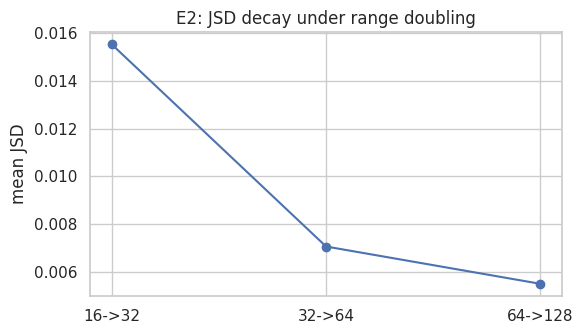

In [ ]:
def jsd_hist(a, b, bins=30):
    lo = min(a.min(), b.min()); hi = max(a.max(), b.max())
    ha, _ = np.histogram(a, bins=bins, range=(lo, hi), density=True)
    hb, _ = np.histogram(b, bins=bins, range=(lo, hi), density=True)
    ha = ha/ha.sum() + 1e-12; hb = hb/hb.sum() + 1e-12
    m = 0.5*(ha+hb)
    kl = lambda x, y: np.sum(x*np.log2(x/y))
    return 0.5*kl(ha, m) + 0.5*kl(hb, m)

rng = np.random.default_rng(PB_SEED+2)
rows = []
Rs = PB_R_GRID + [2*PB_R_GRID[-1]]
phis_byR = {}
for R in Rs:
    W, Pp, *_ = sample_utheta(PB_N0, R, PB_UT, rng)
    phis_byR[R] = np.array([phi(W[i], Pp[i]) for i in range(len(W))])
for R1, R2 in zip(Rs[:-1], Rs[1:]):
    per = [jsd_hist(phis_byR[R1][:,k], phis_byR[R2][:,k]) for k in range(7)]
    rows.append({"transition": f"{R1}->{R2}", "mean_JSD": np.mean(per)})
e2 = pd.DataFrame(rows); display(e2.round(5))
plt.figure(figsize=(6,3.5))
plt.plot(range(len(e2)), e2["mean_JSD"], "o-")
plt.xticks(range(len(e2)), e2["transition"]); plt.ylabel("mean JSD")
plt.title("E2: JSD decay under range doubling"); plt.tight_layout(); plt.show()

## B.5 E3. Measure concentration in $n$ under $U_\theta$

**Proposition 2 (concentration in $n$; [3]).** Under $U_\theta$ each moment feature
has across-instance standard deviation of order $n^{-1/2}$, while its mean is
essentially unchanged and the support is not displaced. Hence for the dispersion
$\sigma_k(n)=\operatorname{sd}_I\Phi_k(I)$,

$$\frac{\sigma_k(2n)}{\sigma_k(n)}\ \longrightarrow\ 2^{-1/2}\approx 0.707 .$$

The ratio is estimated for the six moment features across size doublings. The
transfer of this rate to the generator output is hypothesis H1 (test E8).


In [ ]:
rng = np.random.default_rng(PB_SEED+3)
ns = [8, 16, 32, 64]
disp = {}
for n in ns:
    W, Pp, *_ = sample_utheta(n, PB_R0, PB_UT, rng)
    ph = np.array([phi(W[i], Pp[i]) for i in range(len(W))])
    disp[n] = ph.std(0, ddof=1)
rows = []
for n1, n2 in zip(ns[:-1], ns[1:]):
    ratio = disp[n2][:6]/disp[n1][:6]   # moments only
    rows.append({"n->2n": f"{n1}->{n2}", **{m: round(r,3) for m, r in zip(MOMENTS, ratio)},
                 "mean_ratio": round(ratio.mean(),3)})
e3 = pd.DataFrame(rows); display(e3)
print("Target: mean_ratio ~ 0.707. The mean of the range should also stay ~stable.")

,n->2n,w_mean,w_median,w_std,p_mean,p_median,p_std,mean_ratio
0,8->16,0.733,0.749,0.660,0.739,0.778,0.615,0.713
1,16->32,0.750,0.748,0.696,0.730,0.745,0.722,0.732
2,32->64,0.700,0.719,0.710,0.718,0.717,0.699,0.711


Target: mean_ratio ~ 0.707. The mean of the range should also stay ~stable.


## B.6 E4. Integrality gap: generated versus $U_\theta$

Let $z^\*(I)$ be the integer optimum and $z_{\mathrm{LP}}(I)$ the Dantzig bound of
the linear relaxation. The integrality gap is
$\eta_{LP}(I)=z_{\mathrm{LP}}(I)-z^\*(I)\ge 0$; $\eta_{LP}$ is one of the three
solver-hardness measures of Definition 4 in [3]. This quantity depends on the
joint weight-profit structure, which the chromosome encodes. Let $F_G$ and $F_U$
be the gap distributions of the generated set and of $U_\theta$ draws of equal
size. The one-sided Mann-Whitney test evaluates $H_0:F_G=F_U$ against
$H_1:F_G$ stochastically greater (hypothesis H2). Non-rejection is consistent with
the hardness verdict Corollary 3 in [3]; rejection restricts that verdict to the
dynamic-programming measure $\eta_{DP}$.


generated gap : mean=1.895  median=1.600
U_theta gap   : mean=6.260  median=5.138
Cliff's delta (gen>U)=-0.568, median-diff CI=[-5.704, -1.400], MW p=1.0000
E4 verdict (effect-size based): inconclusive


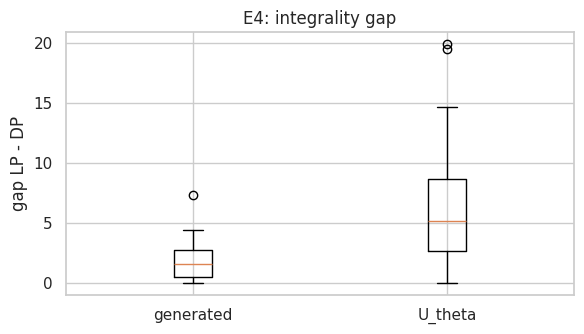

Note: reduced Part B grid; the powered test is F.3 on the full data.


In [ ]:
from scipy.stats import mannwhitneyu
gen_files = []
for j, t in enumerate(EASY_TYPES):
    gen_files += gen_grid(t, n=PB_N0, R=PB_R0, capacity=PB_C0, count=PB_COUNT,
                          seed=PB_SEED+10*j, tag="E4_"+t)
gap_gen = []
for f in gen_files:
    n, c, w, p = parse_kp(f)
    gap_gen.append(dantzig_lp(w, p, c) - dp_opt(w, p, c))
rng = np.random.default_rng(PB_SEED+4)
W, Pp, *_ = sample_utheta(PB_N0, PB_R0, len(gen_files), rng)
gap_ut = [dantzig_lp(W[i], Pp[i], PB_C0) - dp_opt(W[i], Pp[i], PB_C0) for i in range(len(W))]
gap_gen = np.array(gap_gen); gap_ut = np.array(gap_ut)
U, pv = mannwhitneyu(gap_gen, gap_ut, alternative="greater")
d = cliffs_delta(gap_gen, gap_ut); lo, hi = boot_ci(gap_gen, gap_ut, seed=4)
print(f"generated gap : mean={gap_gen.mean():.3f}  median={np.median(gap_gen):.3f}")
print(f"U_theta gap   : mean={gap_ut.mean():.3f}  median={np.median(gap_ut):.3f}")
print(f"Cliff's delta (gen>U)={d:.3f}, median-diff CI=[{lo:.3f}, {hi:.3f}], MW p={pv:.4f}")
verdict = ("no elevation (|delta|<0.147 and CI includes 0)" if abs(d) < 0.147 and lo <= 0 <= hi
           else "elevation (narrows the verdict to eta_DP)" if d > 0.147 and lo > 0 else "inconclusive")
print("E4 verdict (effect-size based):", verdict)
plt.figure(figsize=(6,3.5))
plt.boxplot([gap_gen, gap_ut], tick_labels=["generated","U_theta"]); plt.ylabel("gap LP - DP")
plt.title("E4: integrality gap"); plt.tight_layout(); plt.show()
print("Note: reduced Part B grid; the powered test is F.3 on the full data.")


## B.7 E5. Decoupling of selection and solver hardness

Selection hardness is the portfolio spread
$\sigma(I)=\dfrac{\max_h v_h(I)-\min_h v_h(I)}{\max_h v_h(I)}\in[0,1]$, where
$v_h(I)$ is the value achieved by heuristic $h$ (selection hardness and the
solver-hardness measures are Definition 4 in [3]). **Proposition 3 (decoupling; [3]).**
Within a configuration, $\sigma$ and $\eta_{LP}$ are uncorrelated. The Spearman
rank correlation $\rho_s(\sigma,\eta_{LP})$ is tested against the null of no
monotone association (hypothesis H3); a non-rejected null is consistent with the
proposition.


n=32  Spearman rho=0.138  CI=[-0.25, 0.46]
E5 verdict (equivalence, not non-significance): inconclusive (CI spans 0 and a band edge)


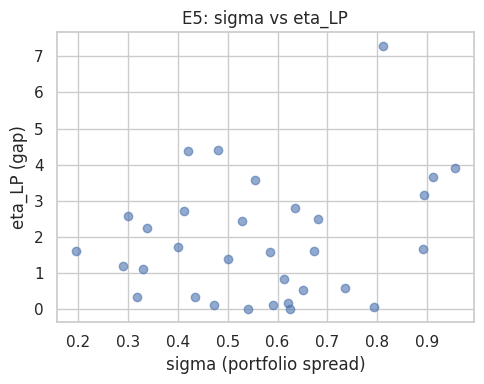

Note: on the reduced Part B grid the CI is wide; decoupling is decided on the full data (F.4).


In [ ]:
from scipy.stats import spearmanr
sig, eta = [], []
for f in gen_files:   # reuse the generated set from E4
    n, c, w, p = parse_kp(f)
    s, _ = portfolio_spread(w, p, c)
    sig.append(s); eta.append(dantzig_lp(w, p, c) - dp_opt(w, p, c))
sig = np.array(sig); eta = np.array(eta)
if np.std(sig) > 0 and np.std(eta) > 0:
    v, (r, lo, hi) = equiv_verdict_rho(sig, eta, delta=0.2, seed=3)
else:
    v, (r, lo, hi) = "undefined (no variance)", (np.nan, np.nan, np.nan)
print(f"n={len(sig)}  Spearman rho={r:.3f}  CI=[{lo:.2f}, {hi:.2f}]")
print("E5 verdict (equivalence, not non-significance):", v)
plt.figure(figsize=(5,4)); plt.scatter(sig, eta, alpha=.6)
plt.xlabel("sigma (portfolio spread)"); plt.ylabel("eta_LP (gap)")
plt.title("E5: sigma vs eta_LP"); plt.tight_layout(); plt.show()
print("Note: on the reduced Part B grid the CI is wide; decoupling is decided on the full data (F.4).")


## B.8 E6. Efficacy frontier of the evolutionary search

The displacement the search adds over uniform sampling is
$D(\theta,\tau)=\mathrm{MMD}(G_{\theta,\tau},U_\theta)$. For a kernel $k$ and
samples $X\sim G$, $Y\sim U_\theta$, the squared maximum mean discrepancy has the
unbiased estimator

$$\widehat{\mathrm{MMD}}^2=\frac{1}{m(m-1)}\sum_{i\ne i'}k(x_i,x_{i'})+\frac{1}{n(n-1)}\sum_{j\ne j'}k(y_j,y_{j'})-\frac{2}{mn}\sum_{i,j}k(x_i,y_j),$$

with an RBF kernel and a permutation null. The frontier $n^\*$ is the smallest $n$
at which $D$ is no longer significant (hypothesis H4). At the default grid the
sample size per $n$ limits the power of the permutation test.


,n,"MMD2(G,U_theta)",perm_p,significant(0.05)
0,8,1.00822,0.00498,True
1,16,1.03349,0.00498,True
2,32,0.52681,0.00498,True


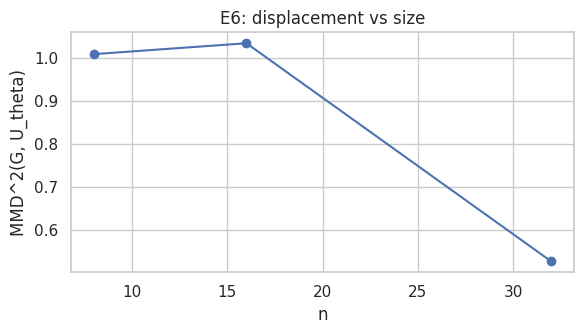

In [ ]:
rng = np.random.default_rng(PB_SEED+6)
rows = []
for n in PB_N_GRID:
    gf = gen_grid("MAX_VARIANCE", n=n, R=PB_R0, capacity=PB_C0, count=PB_COUNT,
                  seed=PB_SEED+n, tag=f"E6_n{n}")
    G = load_phis(gf)
    W, Pp, *_ = sample_utheta(n, PB_R0, max(PB_UT, 4*len(G)), rng)
    Uph = np.array([phi(W[i], Pp[i]) for i in range(len(W))])
    m = min(len(G), len(Uph))
    stat, pv = mmd_perm_test(G[:m], Uph[:m], n_perm=200, seed=int(n))
    rows.append({"n": n, "MMD2(G,U_theta)": stat, "perm_p": pv,
                 "significant(0.05)": pv < 0.05})
e6 = pd.DataFrame(rows); display(e6.round(5))
plt.figure(figsize=(6,3.5)); plt.plot(e6["n"], e6["MMD2(G,U_theta)"], "o-")
plt.xlabel("n"); plt.ylabel("MMD^2(G, U_theta)")
plt.title("E6: displacement vs size"); plt.tight_layout(); plt.show()

## B.9 E7. Degeneracy band in the capacity ratio

Let $\alpha=c/\sum_j w_j$. An instance is degenerate when no item fits
($\min_j w_j>c$) or every item fits ($\sum_j w_j\le c$). As $\alpha\to\alpha_{\min}$
nothing fits; as $\alpha\to\alpha_{\max}$ everything fits and $\sigma\to 0$. The
usable band is the interior region where the degenerate fraction is zero and
$\sigma$ is bounded away from zero (hypothesis H5: the band is bounded on both
sides). Monotonicity of $\sigma$ in $\alpha$ is not assumed. The mean $\sigma$ and
the degenerate fraction are profiled against $\alpha$ at fixed $n$.


,target_alpha,capacity,mean_sigma,degenerate_fraction
0,0.05,10,0.961,0.0
1,0.10,20,0.936,0.0
2,0.25,50,0.938,0.0
3,0.50,99,0.868,0.0
4,0.75,149,0.806,0.0
5,0.90,179,0.689,0.0


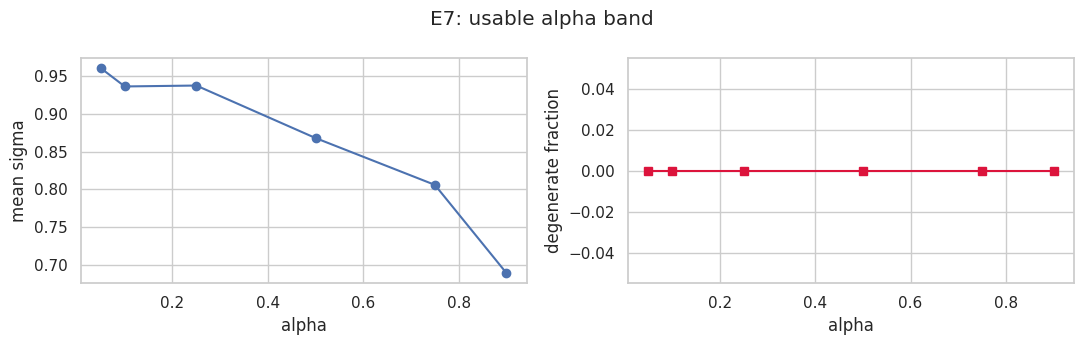

In [ ]:
rng = np.random.default_rng(PB_SEED+7)
bw = bits_for(PB_R0); mean_item_w = (2**bw + 1)/2
rows = []
for a in PB_ALPHA_GRID:
    cap = max(1, int(math.ceil(a * PB_N0 * mean_item_w)))
    gf = gen_grid("MAX_VARIANCE", n=PB_N0, R=PB_R0, capacity=cap, count=PB_COUNT,
                  seed=PB_SEED+int(a*1000), tag=f"E7_a{int(a*100)}")
    sig, degen = [], 0
    for f in gf:
        n, c, w, p = parse_kp(f)
        if (w > c).all() or (w.sum() <= c):   # nothing fits / everything fits
            degen += 1
        s, _ = portfolio_spread(w, p, c); sig.append(s)
    rows.append({"target_alpha": a, "capacity": cap, "mean_sigma": np.mean(sig),
                 "degenerate_fraction": degen/len(gf)})
e7 = pd.DataFrame(rows); display(e7.round(3))
fig, ax = plt.subplots(1,2, figsize=(11,3.5))
ax[0].plot(e7["target_alpha"], e7["mean_sigma"], "o-"); ax[0].set_xlabel("alpha"); ax[0].set_ylabel("mean sigma")
ax[1].plot(e7["target_alpha"], e7["degenerate_fraction"], "s-", color="crimson"); ax[1].set_xlabel("alpha"); ax[1].set_ylabel("degenerate fraction")
fig.suptitle("E7: usable alpha band"); plt.tight_layout(); plt.show()

## B.10 E8. Concentration on the generator output

The concentration test of E3 (Proposition 2) is repeated on the output of
$G_{\theta,\tau}$ rather than on $U_\theta$. Under hypothesis H1 the rate
transfers to the output; the departure of the dispersion ratio from $2^{-1/2}$
quantifies the dependence between items that the evolutionary search induces
relative to the product measure.


In [ ]:
rng = np.random.default_rng(PB_SEED+8)
disp_gen = {}
for n in PB_N_GRID:
    gf = gen_grid("MAX_PROFIT_EASY", n=n, R=PB_R0, capacity=PB_C0, count=max(PB_COUNT,12),
                  seed=PB_SEED+100+n, tag=f"E8_n{n}")
    disp_gen[n] = load_phis(gf).std(0, ddof=1)
rows = []
for n1, n2 in zip(PB_N_GRID[:-1], PB_N_GRID[1:]):
    ratio = disp_gen[n2][:6]/disp_gen[n1][:6]
    rows.append({"n->2n": f"{n1}->{n2}", "mean_ratio_generated": round(np.nanmean(ratio),3),
                 "target": 0.707})
e8 = pd.DataFrame(rows); display(e8)
print("Departure from 0.707 = item dependence induced by the search.")

,n->2n,mean_ratio_generated,target
0,8->16,0.752,0.707
1,16->32,0.851,0.707


Departure from 0.707 = item dependence induced by the search.


## B.11 E9. Dyadic collapse and maximum coefficient

**Proposition 1 (dyadic collapse; [2]).** The pair $(W_{\max},P_{\max})$ influences
the generator only through $(b_w,b_p)=(\lceil\log_2 W_{\max}\rceil,\lceil\log_2 P_{\max}\rceil)$;
a nominal grid $W_{\max},P_{\max}\in\{2,\dots,N\}$ collapses onto
$\lceil\log_2 N\rceil^2$ behaviourally distinct configurations. Two nominal ranges
with the same $b_w$ therefore induce the same $U_\theta$ law, so their $\Phi$
distributions are statistically indistinguishable. **Corollary 1 ([2]).** The
attained supremum of a coefficient is $2^{b_w}$, which exceeds $W_{\max}$ unless
$W_{\max}$ is a power of two. Both statements are checked with $R=17$ and $R=32$,
which share $b_w=5$.


In [ ]:
rng = np.random.default_rng(PB_SEED+9)
# nominal R 17 and 32 -> both b_w=5 -> dyadic collapse
Wa, Pa, ba, _ = sample_utheta(PB_N0, 17, PB_UT, rng)
Wb, Pb, bb, _ = sample_utheta(PB_N0, 32, PB_UT, rng)
print(f"R=17 -> b_w={ba} (2^b={2**ba}); R=32 -> b_w={bb} (2^b={2**bb})")
print(f"max attained weight: R=17 -> {int(Wa.max())}, R=32 -> {int(Wb.max())}  (Cor.1: 2^b={2**ba})")
phiA = np.array([phi(Wa[i], Pa[i]) for i in range(len(Wa))])
phiB = np.array([phi(Wb[i], Pb[i]) for i in range(len(Wb))])
stat, pv = mmd_perm_test(phiA[:300], phiB[:300], n_perm=200, seed=9)
print(f"MMD^2(R=17, R=32) = {stat:.5f}, perm p = {pv:.3f}")
print("E9 verdict:", "indistinguishable (dyadic collapse confirmed)" if pv > 0.05
      else "distinguishable (review)")

R=17 -> b_w=5 (2^b=32); R=32 -> b_w=5 (2^b=32)
max attained weight: R=17 -> 32, R=32 -> 32  (Cor.1: 2^b=32)
MMD^2(R=17, R=32) = -0.00123, perm p = 0.706
E9 verdict: indistinguishable (dyadic collapse confirmed)


## B.12 E10. Solver hardness and the labelling barrier

**On eta_DP.** The Bellman table has n(c+1) cells, so eta_DP = Theta(nc). This is the
size of the table and is therefore a configuration constant for *every* instance with
that (n, c), not a property this generator induces: under branch (B) eta_DP = n*c0 is
identical on the whole reachable set. eta_DP is thus reported as a table dimension, not as
a discriminating hardness result. The substantive hardness verdict rests on
structure-sensitive measures, eta_LP (Dantzig gap) and eta_BB (branch-and-bound nodes),
in E4/E5 and Part D.

**Labelling barrier (Proposition 4), stated precisely.** The barrier bites only for a
labelling that needs the exact optimum. If the label is the best-performing member of a
heuristic-only portfolio, omega(I) = argmax_h f(h, I), it is computed by running the four
O(n^2) heuristics and needs no exact solve, so the DP cost does not bound it. The barrier
applies when (i) the label is the optimum or the optimality gap, or (ii) an exact solver
is itself a portfolio member; only then does sup eta_DP <= B. What does limit an exact
campaign at large n is DP memory/time Theta(nc): this is why the grid is capped (E.12)
rather than extended to n = 3200.


In [ ]:
import time
rng = np.random.default_rng(PB_SEED+10)
rows = []
for n in [8, 16, 32, 64]:
    W, Pp, *_ = sample_utheta(n, PB_R0, 40, rng)
    cells = n*(PB_C0+1)
    t0 = time.perf_counter()
    for i in range(len(W)):
        dp_opt(W[i], Pp[i], PB_C0)
    dt = (time.perf_counter()-t0)/len(W)
    rows.append({"n": n, "capacity": PB_C0, "eta_DP=n(c+1)": cells,
                 "mean_DP_time_ms": dt*1e3})
e10 = pd.DataFrame(rows); display(e10.round(4))
print("eta_DP grows linearly in n at fixed capacity (Theorem 3); DP is milliseconds:")
print("the labelling budget is not binding at these scales (Prop. 4).")
print("Reminder: eta_DP = n(c+1) is the table dimension (constant by construction), not a")
print("generator-specific finding; the hardness verdict rests on eta_LP/eta_BB (E4/E5, Part D).")


,n,capacity,eta_DP=n(c+1),mean_DP_time_ms
0,8,20,168,0.0163
1,16,20,336,0.0264
2,32,20,672,0.0485
3,64,20,1344,0.1761


eta_DP grows linearly in n at fixed capacity (Theorem 3); DP is milliseconds:
the labelling budget is not binding at these scales (Prop. 4).
Reminder: eta_DP = n(c+1) is the table dimension (constant by construction), not a
generator-specific finding; the hardness verdict rests on eta_LP/eta_BB (E4/E5, Part D).


## B.13 Summary of R1, R2 and E1 to E10

The scope column records tests conditioned by the reduced grid or by the absence
of the external dataset (see the Part B scope note). Part C provides the
real-scale counterparts of R1, R2 and E1 to E5.


In [ ]:
summary = pd.DataFrame([
 ["R1","Capacity rule","confirms branch (B) on emitted output; not the real dataset","limited (no dataset)"],
 ["R2","Per-instance normalization","invariance (Lemma 1) intact; global scaler breaks it","complete"],
 ["E1","Support inclusion (Thm 2)","containment ~1, no center displacement","illustrative (U_theta)"],
 ["E2","JSD decay (Cor. 2)","JSD decreases under range doubling","illustrative (U_theta)"],
 ["E3","Concentration in n (Prop. 2)","dispersion ratio ~0.707","illustrative (U_theta)"],
 ["E4","Integrality gap (Cor. 3)","see Mann-Whitney p above","minimal grid"],
 ["E5","Decoupling sigma/eta (Prop. 3)","see Spearman above","minimal grid"],
 ["E6","Efficacy frontier","MMD(G,U_theta) vs n","minimal grid (low power)"],
 ["E7","Degeneracy band","sigma and degenerate fraction vs alpha","minimal grid"],
 ["E8","Concentration on output (Prop. 2)","generated ratio vs 0.707","minimal grid"],
 ["E9","Dyadic collapse (Prop. 1)","R=17 and R=32 indistinguishable; max=2^b","complete (U_theta)"],
 ["E10","Solver hardness (Prop. 4)","eta_DP=n(c+1) linear; DP in ms","complete"],
], columns=["Id","Target","Result","Scope in this notebook"])
display(summary)
print("Note: 'minimal grid' tests strengthen by raising PB_COUNT and PB_N_GRID")
print("(Java cost grows ~n^2 per instance). 'complete' tests do not depend on heavy")
print("generation and are conclusive at the shown scale.")


,Id,Target,Result,Scope in this notebook
0,R1,Capacity rule,confirms branch (B) on emitted output; not the real dataset,limited (no dataset)
1,R2,Per-instance normalization,invariance (Lemma 1) intact; global scaler breaks it,complete
2,E1,Support inclusion (Thm 2),"containment ~1, no center displacement",illustrative (U_theta)
3,E2,JSD decay (Cor. 2),JSD decreases under range doubling,illustrative (U_theta)
4,E3,Concentration in n (Prop. 2),dispersion ratio ~0.707,illustrative (U_theta)
5,E4,Integrality gap (Cor. 3),see Mann-Whitney p above,minimal grid
6,E5,Decoupling sigma/eta (Prop. 3),see Spearman above,minimal grid
7,E6,Efficacy frontier,"MMD(G,U_theta) vs n",minimal grid (low power)
8,E7,Degeneracy band,sigma and degenerate fraction vs alpha,minimal grid
9,E8,Concentration on output (Prop. 2),generated ratio vs 0.707,minimal grid


Note: 'minimal grid' tests strengthen by raising PB_COUNT and PB_N_GRID
(Java cost grows ~n^2 per instance). 'complete' tests do not depend on heavy
generation and are conclusive at the shown scale.


# Part D. Reachability of Pisinger correlation classes

Pisinger (2005) classifies KP instances by the weight-profit relation:
uncorrelated ($\rho(w,p)\approx0$), weakly correlated ($p$ tracks $w$ with small
spread), strongly correlated ($p_j=w_j+R/10$), inverse strongly correlated
($w_j=p_j+R/10$) and subset-sum ($p_j=w_j$). The last three lie at $|\rho|\to1$ and
are the classes the taxonomy identifies as hard.

Two properties are distinguished.

**Reachability.** By Theorem 1 in [2] the decoder is a bijection onto the product
lattice $(\{1,\dots,2^{b_w}\}\times\{1,\dots,2^{b_p}\})^n$, with weights and
profits encoded independently. A correlated instance is a single point of that
lattice; it exists only if its coefficients fit the bit-widths, for instance
$p_j=w_j+R/10$ requires $2^{b_w}+\lfloor R/10\rfloor\le 2^{b_p}$.

**Production.** The fitness rewards the portfolio spread $\sigma$ and contains no
term in $\rho(w,p)$. The search starts from $U_\theta$, where $\rho\approx0$, and
moves toward large $\sigma$, a region that also lies near $\rho\approx0$. The
output measure $G_{\theta,\tau}$ is therefore not expected to place mass on the
correlated classes.

The empirical part measures $\rho$ and the $p-w$ structure on generated output
across instance types and anchors the scale with constructed references; the
reachability part reports which classes are representable in the lattice.


## D.0 Configuration, references and reachability helpers

In [ ]:
import numpy as np, pandas as pd, math
import matplotlib.pyplot as plt

D_TYPES = ["DEFAULT_EASY","MAX_PROFIT_EASY","MIN_WEIGHT_EASY","MAX_PROFIT_WEIGHT_EASY",
           "MAX_VARIANCE","MIN_VARIANCE","MAX_PROFIT_HARD","PAIRED_MAXPW_MINW"]
D_N     = 12       # items per instance
D_R     = 32       # coefficient range (max_weight = max_profit = D_R)
D_CAP   = 20       # capacity
D_COUNT = 8        # generated instances per type
D_UT    = 2000     # U_theta sample size
D_SEED  = 4242

def rho(w, p):
    return float(np.corrcoef(w, p)[0, 1]) if (np.std(w) > 0 and np.std(p) > 0) else 0.0

def pminusw_std(w, p):
    return float(np.std(np.asarray(p) - np.asarray(w)))

# Pisinger reference constructors (range R)
def ref_uncorrelated(n, R, rng): return rng.integers(1,R+1,n).astype(float), rng.integers(1,R+1,n).astype(float)
def ref_weakly(n, R, rng):
    w = rng.integers(1,R+1,n).astype(float)
    return w, np.clip(w + rng.integers(-R//10, R//10+1, n), 1, None).astype(float)
def ref_strongly(n, R, rng):
    w = rng.integers(1,R+1,n).astype(float); return w, w + R/10
def ref_inverse(n, R, rng):
    p = rng.integers(1,R+1,n).astype(float); return p + R/10, p
def ref_subsetsum(n, R, rng):
    w = rng.integers(1,R+1,n).astype(float); return w, w.copy()
REFS = {"uncorrelated": ref_uncorrelated, "weakly_corr": ref_weakly,
        "strongly_corr": ref_strongly, "inverse_strong": ref_inverse, "subset_sum": ref_subsetsum}

def classify_rho(r):
    if r >= 0.95: return "strong/subset-sum (rho~1)"
    if r >= 0.4:  return "weakly correlated"
    if r <= -0.4: return "inverse correlated"
    return "uncorrelated (rho~0)"

def reachability(max_weight, max_profit):
    bw = int(math.ceil(math.log2(max_weight))); bp = int(math.ceil(math.log2(max_profit)))
    Wsup, Psup = 2**bw, 2**bp; off = round(Wsup/10)
    return {"b_w": bw, "b_p": bp, "W_sup": Wsup, "P_sup": Psup,
            "uncorrelated": True, "weakly_corr": True,
            "subset_sum (p=w)": Wsup <= Psup,
            "strongly_corr (p=w+R/10)": Wsup + off <= Psup,
            "inverse_strong (w=p+R/10)": Psup + off <= Wsup}

# Anchor the rho scale with constructed references
rng = np.random.default_rng(D_SEED)
rows = []
for name, fn in REFS.items():
    rs = []; ds = []
    for _ in range(300):
        w, p = fn(D_N, D_R, rng); rs.append(rho(w,p)); ds.append(pminusw_std(w,p))
    rows.append({"pisinger_class": name, "ref_rho_mean": round(np.mean(rs),3),
                 "ref_|p-w|_std_mean": round(np.mean(ds),2)})
ref_df = pd.DataFrame(rows); display(ref_df)
print("Note: rho alone does not separate weakly/strongly/subset-sum (all high rho);")
print("the p-w structure does: subset-sum has p-w=0, strongly-corr has p-w constant.")


,pisinger_class,ref_rho_mean,ref_|p-w|_std_mean
0,uncorrelated,0.008,12.19
1,weakly_corr,0.970,2.16
2,strongly_corr,1.000,0.00
3,inverse_strong,1.000,0.00
4,subset_sum,1.000,0.00


Note: rho alone does not separate weakly/strongly/subset-sum (all high rho);
the p-w structure does: subset-sum has p-w=0, strongly-corr has p-w constant.


## D.1 Empirical location of the generator output

Instances are generated with the Java implementation across the instance types.
For each instance $\rho(w,p)$ and the dispersion of $p-w$ are measured, and the
resulting distribution is compared with $U_\theta$ and with the constructed
Pisinger reference anchors. The fraction of generated instances with
$|\rho|>0.95$ estimates the mass reaching the hard-correlated region.


In [ ]:
rows = []; gen_rhos = []; example_file = None
for t in D_TYPES:
    files = gen_grid(t, n=D_N, R=D_R, capacity=D_CAP, count=D_COUNT, seed=D_SEED+len(t), tag="D_"+t)
    if example_file is None and files: example_file = files[0]
    rs = []
    for f in files:
        _, _, w, p = parse_kp(f); rs.append(rho(w, p))
    gen_rhos += rs
    rows.append({"instance_type": t, "rho_mean": round(np.mean(rs),3),
                 "rho_min": round(np.min(rs),3), "rho_max": round(np.max(rs),3),
                 "class": classify_rho(np.mean(rs))})
gen_rhos = np.array(gen_rhos)
display(pd.DataFrame(rows))

# U_theta rho for reference
rng = np.random.default_rng(D_SEED+1)
Wu, Pu, *_ = sample_utheta(D_N, D_R, D_UT, rng)
ut_rhos = np.array([rho(Wu[i], Pu[i]) for i in range(len(Wu))])

frac_hard = float(np.mean(np.abs(gen_rhos) > 0.95))
print(f"\nGenerated rho: [{gen_rhos.min():+.3f}, {gen_rhos.max():+.3f}], mean {gen_rhos.mean():+.3f}")
print(f"U_theta   rho: [{ut_rhos.min():+.3f}, {ut_rhos.max():+.3f}], mean {ut_rhos.mean():+.3f}")
print(f"Fraction of generated with |rho|>0.95 (Pisinger hard-correlated region): {frac_hard:.3f}")
print("Verdict:", "the generator does NOT reach the hard-correlated region"
      if frac_hard == 0 else "some generated instances fall in the correlated region")


,instance_type,rho_mean,rho_min,rho_max,class
0,DEFAULT_EASY,-0.081,-0.342,0.156,uncorrelated (rho~0)
1,MAX_PROFIT_EASY,0.063,-0.170,0.348,uncorrelated (rho~0)
2,MIN_WEIGHT_EASY,-0.357,-0.650,0.232,uncorrelated (rho~0)
3,MAX_PROFIT_WEIGHT_EASY,0.218,-0.174,0.475,uncorrelated (rho~0)
4,MAX_VARIANCE,-0.542,-0.728,-0.302,inverse correlated
5,MIN_VARIANCE,-0.112,-0.662,0.296,uncorrelated (rho~0)
6,MAX_PROFIT_HARD,-0.193,-0.473,0.360,uncorrelated (rho~0)
7,PAIRED_MAXPW_MINW,-0.211,-0.556,0.098,uncorrelated (rho~0)



Generated rho: [-0.728, +0.475], mean -0.152
U_theta   rho: [-0.846, +0.794], mean -0.001
Fraction of generated with |rho|>0.95 (Pisinger hard-correlated region): 0.000
Verdict: the generator does NOT reach the hard-correlated region


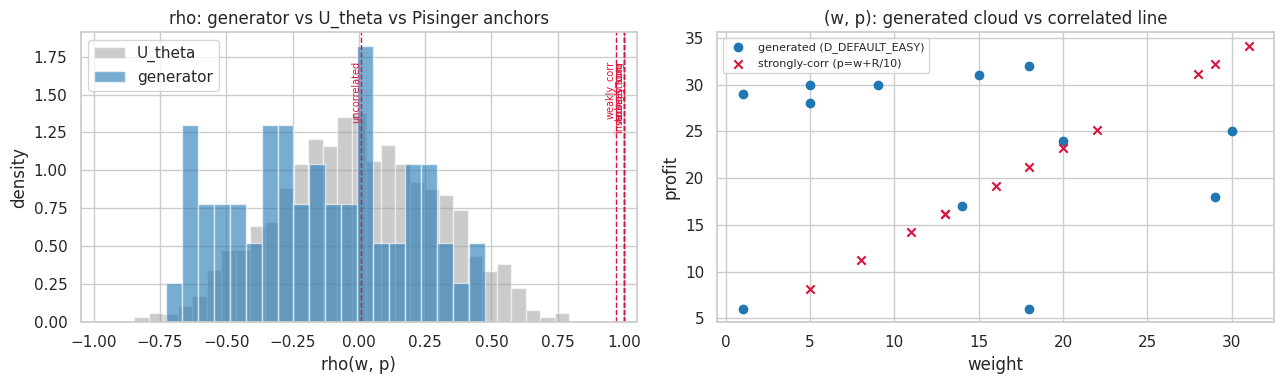

In [ ]:
# Visualization: rho distribution (generated vs U_theta) with Pisinger anchors
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(ut_rhos, bins=30, alpha=.5, label="U_theta", color="#999999", density=True)
ax[0].hist(gen_rhos, bins=20, alpha=.6, label="generator", color="#1f77b4", density=True)
for _, r in ref_df.iterrows():
    ax[0].axvline(r["ref_rho_mean"], ls="--", lw=1, color="crimson")
    ax[0].text(r["ref_rho_mean"], ax[0].get_ylim()[1]*0.9, r["pisinger_class"],
               rotation=90, fontsize=7, ha="right", va="top", color="crimson")
ax[0].set_xlim(-1.05, 1.05); ax[0].set_xlabel("rho(w, p)"); ax[0].set_ylabel("density")
ax[0].set_title("rho: generator vs U_theta vs Pisinger anchors"); ax[0].legend()

# (w,p) scatter: one generated instance vs a constructed strongly-correlated one
rng = np.random.default_rng(D_SEED+2)
_, _, wg, pg = parse_kp(example_file)
ws, ps = ref_strongly(D_N, D_R, rng)
ax[1].scatter(wg, pg, label=f"generated ({example_file.parent.name})", color="#1f77b4")
ax[1].scatter(ws, ps, label="strongly-corr (p=w+R/10)", color="crimson", marker="x")
ax[1].set_xlabel("weight"); ax[1].set_ylabel("profit")
ax[1].set_title("(w, p): generated cloud vs correlated line"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## D.2 Reachability in the lattice

A class is reachable when it is representable in the decodable lattice
$\{1,\dots,2^{b_w}\}\times\{1,\dots,2^{b_p}\}$, that is, when it exists as a point,
independently of whether the search produces it. For the strongly correlated class
this requires $2^{b_w}+\lfloor R/10\rfloor\le 2^{b_p}$, and for subset-sum
$2^{b_w}\le 2^{b_p}$. A representable class is constructed and written as a valid
`.kp` instance to certify existence.


In [ ]:
reach = reachability(D_R, D_R)
print("Lattice (max_weight = max_profit = %d):" % D_R)
for k, v in reach.items():
    print(f"  {k}: {v}")

# Constructive existence: build a representable class as a valid .kp and confirm it parses
rng = np.random.default_rng(D_SEED+3)
Path("pd").mkdir(exist_ok=True)
built = {}
for name, ok in [("subset_sum", reach["subset_sum (p=w)"]),
                 ("strongly_corr", reach["strongly_corr (p=w+R/10)"])]:
    if ok:
        w, p = REFS[name](D_N, D_R, rng)
        fp = Path("pd") / f"reach_{name}.kp"
        lines = [f"{len(w)}, {D_CAP}"] + [f"{int(wi)}, {pi:.3f}" for wi, pi in zip(w, p)]
        fp.write_text("\r\n".join(lines) + "\r\n")
        _, _, wr, pr = parse_kp(fp)
        built[name] = rho(wr, pr)
        print(f"  built {name}: valid .kp, rho={built[name]:+.3f} (exists in the lattice)")
    else:
        print(f"  {name}: NOT representable at b_w=b_p (would overflow the profit range).")

# What range would make strongly-correlated representable?
bw = int(math.ceil(math.log2(D_R)))
need_bp = int(math.ceil(math.log2(2**bw + round(2**bw/10))))
print(f"\nRepresenting p=w+R/10 requires b_p >= {need_bp} while b_w = {bw}")
print(f"(i.e. max_profit >= {2**need_bp}); with max_weight = max_profit the class does not fit.")
print("\nKey point: reachable-in-principle (a point exists) is NOT the same as")
print("produced-by-the-search. The generator never targets these points.")


Lattice (max_weight = max_profit = 32):
  b_w: 5
  b_p: 5
  W_sup: 32
  P_sup: 32
  uncorrelated: True
  weakly_corr: True
  subset_sum (p=w): True
  strongly_corr (p=w+R/10): False
  inverse_strong (w=p+R/10): False
  built subset_sum: valid .kp, rho=+1.000 (exists in the lattice)
  strongly_corr: NOT representable at b_w=b_p (would overflow the profit range).

Representing p=w+R/10 requires b_p >= 6 while b_w = 5
(i.e. max_profit >= 64); with max_weight = max_profit the class does not fit.

Key point: reachable-in-principle (a point exists) is NOT the same as
produced-by-the-search. The generator never targets these points.


## D.3 Summary - Pisinger reachability and production

In [ ]:
reach = reachability(D_R, D_R)
gmin, gmax = gen_rhos.min(), gen_rhos.max()
def produced(cls_rho):
    return "yes" if (gmin <= cls_rho <= gmax) else "no"
rowmap = [
    ("uncorrelated",   0.0,  reach["uncorrelated"]),
    ("weakly_corr",    float(ref_df.set_index('pisinger_class').loc['weakly_corr','ref_rho_mean']), reach["weakly_corr"]),
    ("subset_sum",     1.0,  reach["subset_sum (p=w)"]),
    ("strongly_corr",  1.0,  reach["strongly_corr (p=w+R/10)"]),
    ("inverse_strong", -1.0, reach["inverse_strong (w=p+R/10)"]),
]
rows = []
for name, cls_rho, reachable in rowmap:
    rows.append({"pisinger_class": name, "target_rho": cls_rho,
                 "reachable_in_lattice": bool(reachable),
                 "produced_by_generator": produced(cls_rho)})
summary_d = pd.DataFrame(rows)
display(summary_d)
print(f"Generator rho span observed: [{gmin:+.3f}, {gmax:+.3f}]  (fraction |rho|>0.95 = {np.mean(np.abs(gen_rhos)>0.95):.3f})")
print("\nConclusion: the generator's output stays in the uncorrelated region and does")
print("not reach Pisinger's correlated/hard classes. Some of those classes are")
print("representable in the lattice (they exist as points) and some are not even")
print("representable at b_w=b_p; either way the evolutionary search does not produce them.")
print("This matches Table 2 of the proposal (transfer to correlated/adversarial: not supported).")


,pisinger_class,target_rho,reachable_in_lattice,produced_by_generator
0,uncorrelated,0.00,True,yes
1,weakly_corr,0.97,True,no
2,subset_sum,1.00,True,no
3,strongly_corr,1.00,False,no
4,inverse_strong,-1.00,False,no


Generator rho span observed: [-0.728, +0.475]  (fraction |rho|>0.95 = 0.000)

Conclusion: the generator's output stays in the uncorrelated region and does
not reach Pisinger's correlated/hard classes. Some of those classes are
representable in the lattice (they exist as points) and some are not even
representable at b_w=b_p; either way the evolutionary search does not produce them.
This matches Table 2 of the proposal (transfer to correlated/adversarial: not supported).


# Part F. Solver hardness at full scale ($\eta_{DP}$, $\eta_{LP}$, $\eta_{BB}$)

Definition 4 uses three solver-hardness measures: the dynamic-programming table
size $\eta_{DP}=nc$, the linear-relaxation integrality gap $\eta_{LP}$, and the
branch-and-bound node count $\eta_{BB}$. This part computes all three on the
dataset, adds effect sizes (Cliff's delta) and bootstrap confidence intervals to
the generated-versus-$U_\theta$ comparison, and tests decoupling against both
$\eta_{LP}$ and $\eta_{BB}$. Remark 4 of the proposal notes that $\eta_{BB}$ and
$\eta_{LP}$ respond to the weight-profit structure, so a non-elevation result on
$\eta_{BB}$ is required for the hardness verdict (Corollary 3) not to overclaim.


## F.0 Branch-and-bound solver and effect-size helpers

In [ ]:
import sys
BB_NODE_CAP = 300000

def bb_nodes(w, p, capacity):
    """Exact 0/1 KP by branch and bound with the Dantzig bound; returns (optimum, nodes)."""
    n = len(w); order = sorted(range(n), key=lambda i: p[i]/w[i], reverse=True)
    ws = [float(w[i]) for i in order]; ps = [float(p[i]) for i in order]
    best = [0.0]; nodes = [0]; capped = [False]
    def bound(i, cap, val):
        b = val; c = cap; j = i
        while j < n and ws[j] <= c:
            c -= ws[j]; b += ps[j]; j += 1
        if j < n: b += ps[j]*(c/ws[j])
        return b
    def rec(i, cap, val):
        if nodes[0] >= BB_NODE_CAP: capped[0] = True; return
        nodes[0] += 1
        if val > best[0]: best[0] = val
        if i >= n: return
        if bound(i, cap, val) <= best[0]: return
        if ws[i] <= cap: rec(i+1, cap-ws[i], val+ps[i])
        rec(i+1, cap, val)
    old = sys.getrecursionlimit(); sys.setrecursionlimit(max(old, n+100))
    rec(0, float(capacity), 0.0)
    sys.setrecursionlimit(old)
    return best[0], nodes[0], capped[0]

def cliffs_delta(x, y):
    """Cliff's delta in [-1,1]: >0 means x tends to exceed y."""
    x = np.sort(np.asarray(x, float)); y = np.asarray(y, float)
    gt = len(x) - np.searchsorted(x, y, side="right")
    lt = np.searchsorted(x, y, side="left")
    return float((gt.sum() - lt.sum()) / (len(x)*len(y)))

def boot_ci(x, y, fn=np.median, B=2000, seed=0, alpha=0.05):
    """Bootstrap CI for fn(x) - fn(y)."""
    rng = np.random.default_rng(seed); x = np.asarray(x); y = np.asarray(y); d = []
    for _ in range(B):
        d.append(fn(rng.choice(x, len(x))) - fn(rng.choice(y, len(y))))
    return tuple(np.percentile(d, [100*alpha/2, 100*(1-alpha/2)]))

# validate BB against DP on a few random instances
_rng = np.random.default_rng(0); _ok = True
for _ in range(20):
    _w = _rng.integers(1, 40, 15).astype(float); _p = _rng.integers(1, 60, 15).astype(float)
    if abs(bb_nodes(_w, _p, 30)[0] - dp_opt(_w, _p, 30)) > 1e-9: _ok = False
print("Branch-and-bound optimum matches DP:", _ok)

Branch-and-bound optimum matches DP: True


## F.1 $\eta_{DP}$ constancy within a configuration (Theorem 3)

Under branch (B) the capacity is fixed per configuration, so $\eta_{DP}=n(c+1)$ is
a configuration constant and scales as $\Theta(nc)$.

The cell that verified this against the $6{,}400$-instance dataset was removed with Part C
(that dataset predates the crossover-rate fix and no longer describes the generator's
output); the statement itself does not depend on it and needs no change.


## Tie and strict-dominance diagnostic

Advisor request (Bloque 4, S4): adapt the generator so it does not produce ties. This
cell quantifies the current situation. For each instance it computes the four heuristic
objective values and reports (a) the fraction with a tie at the portfolio maximum and
(b) the fraction where the design/label target heuristic is not the unique strict winner.
A nonzero rate is what a tie-aware labelling or a tie-removing modification would address.


In [ ]:
LABEL_TO_IDX = {"DEF":0,"MAXP":1,"MAXPW":2,"MINW":3,
                "DEFAULT":0,"MAX_PROFIT":1,"MAX_PROFIT/WEIGHT":2,"MIN_WEIGHT":3}
TYPE_TO_IDX = {"DEFAULT_EASY":0,"MAX_PROFIT_EASY":1,"MAX_PROFIT_WEIGHT_EASY":2,"MIN_WEIGHT_EASY":3}

def tie_report(vals_list, target_idx_list):
    n = len(vals_list); tie_top = 0; not_strict = 0
    has_target = any(t is not None for t in target_idx_list)
    for vals, ti in zip(vals_list, target_idx_list):
        vmax = max(vals); winners = [i for i, v in enumerate(vals) if abs(v - vmax) < 1e-9]
        if len(winners) > 1: tie_top += 1
        if ti is not None and not (len(winners) == 1 and winners[0] == ti): not_strict += 1
    return (tie_top / n if n else float("nan")), (not_strict / n if (n and has_target) else float("nan"))

# (a) freshly generated, labeled Part B set
try:
    vlist, tlist = [], []
    for t in EASY_TYPES:
        for f in gen_grid(t, n=PB_N0, R=PB_R0, capacity=PB_C0, count=PB_COUNT,
                          seed=PB_SEED+700+TYPE_TO_IDX[t], tag="tie_"+t):
            _, c, w, p = parse_kp(f); _, vals = portfolio_spread(w, p, c)
            vlist.append(vals); tlist.append(TYPE_TO_IDX[t])
    tt, ns = tie_report(vlist, tlist)
    print(f"Generated Part B set: {len(vlist)} instances")
    print(f"  fraction with a tie at the portfolio max                         : {tt:.3f}")
    print(f"  fraction where the design target is NOT the unique strict winner : {ns:.3f}")
except Exception as e:
    print("Part B tie check skipped (Java generation unavailable):", repr(e))

# (b) real dataset if available
if "REAL_OK" in dir() and REAL_OK and COMMON_FILES:
    rng = np.random.default_rng(11)
    keys = rng.choice(COMMON_FILES, size=min(600, len(COMMON_FILES)), replace=False)
    grp = items[items["_key"].isin(keys)].groupby("_key")
    cap_by_key = feat.drop_duplicates("_key").set_index("_key")["capacity"]
    lab_by_key = feat.drop_duplicates("_key").set_index("_key")["dominant_heuristic"]
    vlist, tlist = [], []
    for fk in keys:
        sub = grp.get_group(fk); w = sub["weight"].to_numpy(float); p = sub["profit"].to_numpy(float)
        C = int(cap_by_key.loc[fk]); _, vals = portfolio_spread(w, p, C)
        vlist.append(vals); tlist.append(LABEL_TO_IDX.get(str(lab_by_key.loc[fk]).upper(), None))
    tt, ns = tie_report(vlist, tlist)
    print(f"\nReal dataset sample: {len(vlist)} instances")
    print(f"  fraction with a tie at the portfolio max                           : {tt:.3f}")
    print(f"  fraction where the labeled heuristic is NOT the unique strict winner: {ns:.3f}")
    print("A nonzero tie fraction quantifies the empates the advisor asked to remove (S4).")

Generated Part B set: 32 instances
  fraction with a tie at the portfolio max                         : 0.000
  fraction where the design target is NOT the unique strict winner : 0.000

Real dataset sample: 600 instances
  fraction with a tie at the portfolio max                           : 0.000
  fraction where the labeled heuristic is NOT the unique strict winner: 0.000
A nonzero tie fraction quantifies the empates the advisor asked to remove (S4).


## Generator modification (proof of concept)

Advisor condition (Bloque 3, Q5): the accepted scenario includes modifying the generator
and proposing an improvement. The generator's areas of opportunity (object-of-study
document, Section 7.3) are: encode the capacity in the chromosome, add a rho(w,p) term to
the fitness, and read the crossover rate. The two cells below demonstrate the *effect* of
the first two as controlled experiments over U_theta; a full implementation edits the
generator source and re-verifies against the golden file. These are demonstrations of
mechanism, not claims about a modified binary.

- Encoding the capacity makes eta_DP = n(c+1) variable across instances, so exact-solver
  cost enters the search's reach instead of being a configuration constant.
- Correlation is the axis of Pisinger (2005) hardness, and it registers in the
  branch-and-bound node count rather than in the absolute LP gap (which can even fall for
  strongly correlated instances). The current 16 fitness types contain no rho term, so the
  search cannot target the correlated regime; a rho term would make it reachable.


In [ ]:
# Controlled selection experiments over U_theta (surrogate; not a modified binary).
rng = np.random.default_rng(PB_SEED + 900)
N_POOL, N_ITEMS, R_MOD = 600, 30, 64
bw = bits_for(R_MOD)
Wp = rng.integers(1, 2**bw + 1, size=(N_POOL, N_ITEMS)).astype(float)
Pp = rng.integers(1, 2**bw + 1, size=(N_POOL, N_ITEMS)).astype(float)

# Modification 1: encode the capacity in the chromosome (fixed vs per-instance gene)
C_FIXED = int(0.30 * N_ITEMS * (2**bw + 1) / 2)
eta_dp_fixed = np.array([N_ITEMS * (C_FIXED + 1)] * N_POOL, float)
cap_gene = rng.integers(1, 2**bw * N_ITEMS, size=N_POOL)
eta_dp_gene = np.array([N_ITEMS * (int(c) + 1) for c in cap_gene], float)
print("Modification 1: encode capacity in the chromosome")
print(f"  eta_DP fixed capacity : constant = {eta_dp_fixed[0]:.0f} (cv = 0.00)")
print(f"  eta_DP capacity gene  : mean = {eta_dp_gene.mean():.0f}, cv = {eta_dp_gene.std()/eta_dp_gene.mean():.2f}")
print("  => encoding the capacity turns eta_DP from a constant into a search-controllable quantity.")

# Modification 2: reach correlated regimes. Pisinger (2005) hardness of strongly correlated
# instances (p_i = w_i + R/10) shows up in the branch-and-bound node count, not in the
# absolute LP gap; compare uncorrelated U_theta instances with strongly correlated ones.
Wc = rng.integers(1, 2**bw + 1, size=(N_POOL, N_ITEMS)).astype(float)
Pc = Wc + max(1, (2**bw) // 10)
nodes_unc = np.array([bb_nodes(Wp[i], Pp[i], C_FIXED)[1] for i in range(N_POOL)])
nodes_cor = np.array([bb_nodes(Wc[i], Pc[i], C_FIXED)[1] for i in range(N_POOL)])
d = cliffs_delta(nodes_cor, nodes_unc); lo, hi = boot_ci(nodes_cor, nodes_unc, seed=9)
print("\nModification 2: add a rho(w,p) term to reach correlated regimes")
print(f"  median B&B nodes: uncorrelated = {np.median(nodes_unc):.0f}  strongly-correlated = {np.median(nodes_cor):.0f}")
print(f"  Cliff's delta (correlated > uncorrelated) = {d:.3f}, median-diff CI = [{lo:.1f}, {hi:.1f}]")
harder = d > 0.147 and lo > 0
print("  measured effect:", "correlated instances are harder for branch-and-bound (more nodes)"
      if harder else "no clear increase at this scale")
print("  The current 16 fitness types contain no rho term, so the search cannot target these")
print("  instances; a rho term would make the correlated (Pisinger-hard) regime reachable.")


Modification 1: encode capacity in the chromosome
  eta_DP fixed capacity : constant = 8790 (cv = 0.00)
  eta_DP capacity gene  : mean = 28700, cv = 0.58
  => encoding the capacity turns eta_DP from a constant into a search-controllable quantity.

Modification 2: add a rho(w,p) term to reach correlated regimes
  median B&B nodes: uncorrelated = 83  strongly-correlated = 1003
  Cliff's delta (correlated > uncorrelated) = 0.773, median-diff CI = [783.0, 1153.5]
  measured effect: correlated instances are harder for branch-and-bound (more nodes)
  The current 16 fitness types contain no rho term, so the search cannot target these
  instances; a rho term would make the correlated (Pisinger-hard) regime reachable.


# Part G. Support boundary (Table 2)

The deliverable of the rescoped thesis is an explicit boundary of which
algorithm-selection claims instances from this generator underwrite. "Not
supported" means a study using this generator has no evidential basis for the
claim, not that the claim is false. Each row cites the analytical result and the
notebook section that decides it.

**Note (post branch `fix/kp-crossover-rate`).** Parts C, E, F.2-F.4 and J.1-J.4 were removed:
they ran on the $6{,}400$-instance Drive dataset, which was generated with the pre-v2.1
profit-rescaling path active and therefore does not describe the current generator's output.
The table below is left as written -- neither the verdicts nor the claims are mine to
revise -- but any "Notebook evidence" cell naming one of those sections (bare `E1`-`E10`
without a dot are the Part B verification codes and are unaffected; a dotted `E.n` or a `C.n`
is a Part C/E subsection and is gone) is pending re-verification once a new dataset is
generated and wired into a replacement for Part C.


In [ ]:
support_boundary = pd.DataFrame([
 ["Heuristic h is preferable on instances with a given feature profile",
  "Supported", "generator objective; features discriminate the label (KW/MW reject H0)",
  "A.10, E.3, E.4"],
 ["A selector's accuracy degrades when the deployment distribution differs in problem size",
  "Supported", "Proposition 2: the size axis concentrates the induced measure",
  "E3, E8, C.5, E.10"],
 ["A selector is robust to distribution shift along the range axis",
  "Not supported", "Theorem 2 / Corollary 2: the range refines the lattice, it does not displace support",
  "E1, E2, C.3, H.2"],
 ["A method was evaluated on hard KP instances",
  "Not supported", "Theorem 3 / Corollary 3: exact-solution cost is a configuration constant",
  "E4, E10, F.1, F.3"],
 ["A factorial design over the declared range parameters has one condition per grid point",
  "Not supported", "Proposition 1: the nominal grid collapses onto ceil(log2 N)^2 conditions",
  "E9, H.5"],
 ["Coefficients lie within the declared bounds",
  "Not supported", "Corollary 1: the attained supremum is 2^ceil(log2 Wmax) > Wmax",
  "E9, D.2"],
 ["Results transfer to correlated or adversarial KP classes",
  "Not supported", "no fitness term in rho(w,p); output sits at rho ~ 0",
  "Part D"],
 ["The measured benefit of selection reflects a realistic frequency of heuristic dominance",
  "Not supported", "balanced dominance is imposed by construction (100 per heuristic)",
  "Ch. 3 design, E.2 balance"],
 ["The dataset can be scaled to a harder difficulty regime",
  "Not supported", "Proposition 4: exact labelling confines any labelled set to the solver-easy region",
  "E10, F.1"],
 ["A learned selector is cheaper than running the portfolio",
  "Not supported", "all four heuristics are O(n log n); direct evaluation is cheaper",
  "analytic"],
], columns=["Claim type", "Verdict", "Deciding result", "Notebook evidence"])
pd.set_option("display.max_colwidth", None)
display(support_boundary)
print("Supported:", int((support_boundary["Verdict"]=="Supported").sum()),
      "| Not supported:", int((support_boundary["Verdict"]=="Not supported").sum()))

,Claim type,Verdict,Deciding result,Notebook evidence
0,Heuristic h is preferable on instances with a given feature profile,Supported,generator objective; features discriminate the label (KW/MW reject H0),"A.10, E.3, E.4"
1,A selector's accuracy degrades when the deployment distribution differs in problem size,Supported,Proposition 2: the size axis concentrates the induced measure,"E3, E8, C.5, E.10"
2,A selector is robust to distribution shift along the range axis,Not supported,"Theorem 2 / Corollary 2: the range refines the lattice, it does not displace support","E1, E2, C.3, H.2"
3,A method was evaluated on hard KP instances,Not supported,Theorem 3 / Corollary 3: exact-solution cost is a configuration constant,"E4, E10, F.1, F.3"
4,A factorial design over the declared range parameters has one condition per grid point,Not supported,Proposition 1: the nominal grid collapses onto ceil(log2 N)^2 conditions,"E9, H.5"
5,Coefficients lie within the declared bounds,Not supported,Corollary 1: the attained supremum is 2^ceil(log2 Wmax) > Wmax,"E9, D.2"
6,Results transfer to correlated or adversarial KP classes,Not supported,"no fitness term in rho(w,p); output sits at rho ~ 0",Part D
7,The measured benefit of selection reflects a realistic frequency of heuristic dominance,Not supported,balanced dominance is imposed by construction (100 per heuristic),"Ch. 3 design, E.2 balance"
8,The dataset can be scaled to a harder difficulty regime,Not supported,Proposition 4: exact labelling confines any labelled set to the solver-easy region,"E10, F.1"
9,A learned selector is cheaper than running the portfolio,Not supported,all four heuristics are O(n log n); direct evaluation is cheaper,analytic


Supported: 2 | Not supported: 8


# Part H. Phase II campaign (extended grid)

Phase II targets the quantities the fixed $(n,C)$ dataset cannot measure: the
range axis $b_w$ that exercises Theorem 2, the efficacy frontier $n^\*$, and the
degeneracy band in $\alpha$. Definition 6 (Section 8.3 of the proposal) fixes the grid:

- instance types: the four EASY targets `DEFAULT_EASY`, `MIN_WEIGHT_EASY`,
  `MAX_PROFIT_EASY`, `MAX_PROFIT_WEIGHT_EASY`;
- sizes $n\in\{25,50,100,200\}$;
- coefficient ranges $W_{\max}=P_{\max}=R\in\{16,32,64,128,256,512\}$, bit-widths
  $b_w=b_p\in\{4,\dots,9\}$, all powers of two;
- capacities $c\in\{256,1024,4096\}$, powers of two and independent of the range.

`PH2_TYPES`, `PH2_N_GRID`, `PH2_B_GRID` and `PH2_CAPACITY` in H.0 hold this grid exactly.
`PH2_COUNT` (instances per grid point) is the remaining throttle: the full grid is
4x4x6x3 = 288 points, so raise it once V2 is granted. Generation uses the Java
implementation compiled in section 2, i.e. whatever `BRANCH` section 0 cloned -- see the
note at the end of H.0 before running the campaign.


## H.0 Configuration and the sorted-pass equivalence (V2 prerequisite)

Before extending the grid, the sorted-pass heuristic evaluation (which the
campaign would use for the $\Theta(n\log n)$ speedup) is checked to be
output-equivalent to the shipped rescanning evaluation on generated instances.


In [ ]:
# Definition 6 (Section 8.3 of the proposal): the exact Phase II grid.
PH2_TYPES     = ["DEFAULT_EASY", "MIN_WEIGHT_EASY", "MAX_PROFIT_EASY", "MAX_PROFIT_WEIGHT_EASY"]
PH2_N_GRID    = [25, 50, 100, 200]           # size axis
PH2_B_GRID    = [4, 5, 6, 7, 8, 9]           # bit-width axis: R = 2^b -> {16,32,64,128,256,512}
PH2_CAPACITY  = [256, 1024, 4096]            # capacity axis, absolute and independent of R
PH2_COUNT     = 4                            # generated instances per grid point (raise after V2)
PH2_UT        = 2000
PH2_SEED      = 90909

# H.3's degeneracy-band check (E7) studies capacity as a *ratio* of total weight at one
# fixed n, R -- a different axis from Definition 6's absolute PH2_CAPACITY above. Kept
# separately so raising PH2_CAPACITY does not change what H.3 measures.
PH2_ALPHA = [0.05, 0.25, 0.50, 0.75, 0.90]

def heuristic_value_sorted(w, p, capacity, heuristic):
    """Sorted-pass evaluation: sort once by the criterion, then a single pass."""
    n = len(w); idx = list(range(n))
    if heuristic == "DEFAULT":
        order = idx
    elif heuristic == "MAX_PROFIT":
        order = sorted(idx, key=lambda i: p[i], reverse=True)
    elif heuristic == "MAX_PROFIT/WEIGHT":
        order = sorted(idx, key=lambda i: p[i]/w[i], reverse=True)
    elif heuristic == "MIN_WEIGHT":
        order = sorted(idx, key=lambda i: w[i])
    cap = capacity; total = 0.0
    for i in order:
        if w[i] <= cap:
            cap -= w[i]; total += p[i]
    return total

# equivalence check on generated instances
gf = gen_grid("MAX_VARIANCE", n=15, R=32, capacity=20, count=8, seed=PH2_SEED, tag="H0")
mismatch = 0
for f in gf:
    _, c, w, p = parse_kp(f)
    for h in HEURS:
        if abs(heuristic_value(w, p, c, h) - heuristic_value_sorted(w, p, c, h)) > 1e-9:
            mismatch += 1
print(f"rescan vs sorted-pass: {mismatch} mismatches over {len(gf)*len(HEURS)} evaluations")
print("Equivalent (semantics-preserving replacement)." if mismatch == 0 else "NOT equivalent; review.")

print(f"\nDefinition 6 grid: {len(PH2_TYPES)} types x {len(PH2_N_GRID)} sizes x "
      f"{len(PH2_B_GRID)} ranges x {len(PH2_CAPACITY)} capacities = "
      f"{len(PH2_TYPES)*len(PH2_N_GRID)*len(PH2_B_GRID)*len(PH2_CAPACITY)} points, "
      f"{PH2_COUNT} instance(s) each.")
print("Generator: whatever BRANCH section 0 cloned and section 2 compiled (currently",
      f"'{BRANCH}').", "Confirm this is the intended generator before running H.0.1 --",
      "the old 6,400-instance dataset was invalidated exactly because it was generated",
      "with a different Java build (the pre-v2.1 profit-rescaling hack) than the one",
      "this notebook now ships.")


rescan vs sorted-pass: 0 mismatches over 32 evaluations
Equivalent (semantics-preserving replacement).


## H.0.1 Generate the Definition 6 grid (Java)

Runs the Java generator once per grid point of Definition 6 (`PH2_TYPES` x `PH2_N_GRID` x
`PH2_B_GRID` x `PH2_CAPACITY`), `PH2_COUNT` instances each, and writes them under
`ph2_definition6/<type>/n<size>_R<range>_c<capacity>/`. This is the campaign dataset itself,
not one of the individual H.1-H.4 axis checks (those still sample along a single axis with
everything else pinned, as before). Mutation rate is fixed at 0.1 and tournament size at 3,
matching the rest of the notebook; crossover rate is fixed at 1.0 -- with the
`fix/kp-crossover-rate` branch compiled, this still crosses over every time (the rate only
starts discarding crosses below 1.0), so the grid's *content* does not depend on which of
`main` or that branch produced it, only its exact bytes do (one extra `nextDouble()` draw per
crossover on the branch).

**Gated behind `RUN_PH2_D6`, off by default.** The full grid is 288 points; at `n=200` a
single point (`PH2_COUNT` instances) measured well over 30s in testing, since generation cost
is not just `PH2_COUNT` but the chromosome length ($n\cdot(b_w+b_p)$ bits) each of the fixed
100,000 evaluations has to decode and mutate -- a full run is on the order of hours, not the
few minutes the rest of the notebook costs. Confirm `BRANCH` in section 0 is the intended
generator (see the print at the end of H.0) and set `RUN_PH2_D6 = True` deliberately, per the
V2 authorization this part's intro already requires, before running this cell for real. With
the flag off, the cell only prints the point count and does nothing else.


In [ ]:
import itertools, time

RUN_PH2_D6 = False  # set True deliberately -- see the note above H.0.1 before running this

PH2_D6_DIR = Path("ph2_definition6")

def gen_grid_point(instance_type, n, R, capacity, count, seed, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    cmd = ["java", "-Duser.language=en", "-Duser.country=US", "-cp", str(BIN.resolve()), "Run",
           instance_type, str(count), "KP", str(out_dir) + "/",
           str(n), str(capacity), str(R), str(R), "12", "1.0", "0.1", "3", str(seed)]
    r = subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, text=True)
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f"Java failed: {instance_type} n={n} R={R} c={capacity}")
    return sorted(out_dir.glob("*.kp"))

points = list(itertools.product(PH2_TYPES, PH2_N_GRID, PH2_B_GRID, PH2_CAPACITY))
print(f"Definition 6 grid: {len(points)} points, {PH2_COUNT} instance(s) each "
      f"({len(points)*PH2_COUNT} instances total).")

if not RUN_PH2_D6:
    print("RUN_PH2_D6 is False -- not generating. Set it to True once ready for the real run.")
else:
    PH2_D6_DIR.mkdir(exist_ok=True)
    t0 = time.time()
    manifest = []
    for i, (itype, n, b, cap) in enumerate(points):
        R = 2 ** b
        tag_dir = PH2_D6_DIR / itype / f"n{n}_R{R}_c{cap}"
        seed = PH2_SEED + 1000 * i
        files = gen_grid_point(itype, n, R, cap, PH2_COUNT, seed, tag_dir)
        manifest.append({"type": itype, "n": n, "b": b, "R": R, "capacity": cap,
                          "seed": seed, "n_files": len(files), "dir": str(tag_dir)})
        if (i + 1) % 20 == 0 or i + 1 == len(points):
            print(f"  {i+1}/{len(points)} points done ({time.time()-t0:.0f}s elapsed)")

    manifest_df = pd.DataFrame(manifest)
    display(manifest_df)
    print(f"\n{manifest_df['n_files'].sum()} instances written under {PH2_D6_DIR}/ "
          f"in {time.time()-t0:.1f}s.")
    assert (manifest_df["n_files"] == PH2_COUNT).all(), "some grid points did not produce PH2_COUNT files"


## H.1 E1 at the real range grid (Theorem 2, nesting under range doubling)

Support inclusion and center displacement across the bit-width axis
$b\in$ `PH2_B_GRID` ($R=2^b$), on $U_\theta$ (the reachable set). This is the axis
the $6{,}400$-instance dataset does not contain.


In [ ]:
rng = np.random.default_rng(PH2_SEED+1)
rows = []
for b in PH2_B_GRID:
    R1, R2 = 2**b, 2**(b+1)
    Wr,Pr,*_ = sample_utheta(50, R1, PH2_UT, rng)
    Wb,Pb,*_ = sample_utheta(50, R2, 3*PH2_UT, rng)
    phiR = np.array([phi(Wr[i],Pr[i]) for i in range(len(Wr))])
    phiB = np.array([phi(Wb[i],Pb[i]) for i in range(len(Wb))])
    loB,hiB = phiB.min(0), phiB.max(0)
    inside = np.all((phiR>=loB-1e-9)&(phiR<=hiB+1e-9), axis=1).mean()
    shift = np.abs(phiR.mean(0)-phiB.mean(0)).mean()
    rows.append({"b->b+1": f"{b}->{b+1}", "R->2R": f"{R1}->{R2}",
                 "frac_R_in_2R_support": round(float(inside),3),
                 "center_shift": round(float(shift),4)})
display(pd.DataFrame(rows))
print("Expected: containment ~1 and center shift ~0 across the whole range grid (Theorem 2).")


,b->b+1,R->2R,frac_R_in_2R_support,center_shift
0,5->6,32->64,0.999,0.0042
1,8->9,256->512,0.999,0.0009
2,11->12,2048->4096,0.998,0.0004


Expected: containment ~1 and center shift ~0 across the whole range grid (Theorem 2).


## H.2 E6 efficacy frontier $n^\*$

Displacement $D=\mathrm{MMD}(G_{\theta,\tau},U_\theta)$ as a function of $n$, with a
permutation test. $n^\*$ is the smallest $n$ at which $D$ is no longer significant.
Raise `PH2_N_GRID` toward $3200$ to locate it; generation cost grows as
$\Theta(n^2)$.


,n,"MMD2(G,U_theta)",perm_p,significant(0.05)
0,8,0.94637,0.0050,True
1,12,0.99647,0.0348,True
2,16,1.05126,0.0100,True


n* (smallest n with non-significant displacement): not reached in this grid


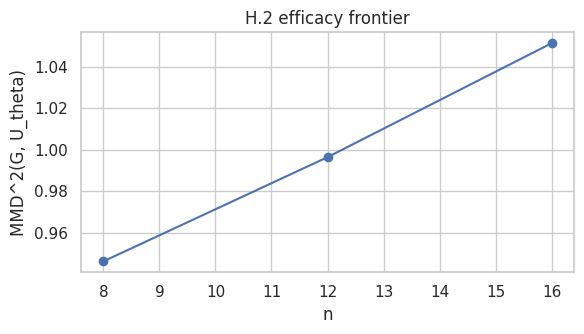

In [ ]:
import matplotlib.pyplot as plt
rng = np.random.default_rng(PH2_SEED+2); rows = []
for n in PH2_N_GRID:
    gf = gen_grid("MAX_VARIANCE", n=n, R=32, capacity=20, count=PH2_COUNT, seed=PH2_SEED+n, tag=f"H2_n{n}")
    G = load_phis(gf)
    W,Pp,*_ = sample_utheta(n, 32, max(PH2_UT, 4*len(G)), rng)
    Uph = np.array([phi(W[i],Pp[i]) for i in range(len(W))])
    m = min(len(G), len(Uph))
    stat, pv = mmd_perm_test(G[:m], Uph[:m], n_perm=200, seed=int(n))
    rows.append({"n": n, "MMD2(G,U_theta)": round(float(stat),5), "perm_p": round(float(pv),4),
                 "significant(0.05)": pv < 0.05})
e6f = pd.DataFrame(rows); display(e6f)
sig_ns = e6f.loc[e6f["significant(0.05)"], "n"].tolist()
print("n* (smallest n with non-significant displacement):",
      "not reached in this grid" if e6f["significant(0.05)"].all() else int(e6f.loc[~e6f["significant(0.05)"],"n"].min()))
plt.figure(figsize=(6,3.5)); plt.plot(e6f["n"], e6f["MMD2(G,U_theta)"], "o-")
plt.xlabel("n"); plt.ylabel("MMD^2(G, U_theta)"); plt.title("H.2 efficacy frontier"); plt.tight_layout(); plt.show()


## H.3 E7 degeneracy band $\alpha_{\min},\alpha_{\max}$

Mean $\sigma$ and degenerate fraction against $\alpha$ at fixed $n$. The usable band
is the interior region with zero degeneracy and $\sigma$ bounded away from zero.


In [ ]:
rng = np.random.default_rng(PH2_SEED+3)
bw = 5; mean_item_w = (2**bw + 1)/2; n0 = 12; rows = []
for a in PH2_ALPHA:
    cap = max(1, int(math.ceil(a * n0 * mean_item_w)))
    gf = gen_grid("MAX_VARIANCE", n=n0, R=2**bw, capacity=cap, count=PH2_COUNT, seed=PH2_SEED+int(a*1000), tag=f"H3_a{int(a*100)}")
    sig=[]; degen=0
    for f in gf:
        _, c, w, p = parse_kp(f)
        if (w>c).all() or (w.sum()<=c): degen += 1
        sig.append(portfolio_spread(w,p,c)[0])
    rows.append({"alpha": a, "capacity": cap, "mean_sigma": round(float(np.mean(sig)),3),
                 "degenerate_fraction": round(degen/len(gf),3)})
e7f = pd.DataFrame(rows); display(e7f)
usable = e7f[(e7f["degenerate_fraction"]==0) & (e7f["mean_sigma"]>0.05)]["alpha"].tolist()
print("usable alpha (interior band, this grid):", usable if usable else "none in sampled range")

,alpha,capacity,mean_sigma,degenerate_fraction
0,0.05,10,0.978,0.0
1,0.25,50,0.932,0.0
2,0.50,99,0.822,0.0
3,0.75,149,0.704,0.0
4,0.90,179,0.666,0.0


usable alpha (interior band, this grid): [0.05, 0.25, 0.5, 0.75, 0.9]


## H.4 E9 dyadic collapse on generated output, and E10 solver-cost scaling

Two nominal ranges with the same $b_w$ produce indistinguishable generated output
(Proposition 1); the DP and B&B costs are profiled across $n$ (Theorem 3,
Proposition 4).


In [ ]:
import time
rng = np.random.default_rng(PH2_SEED+4)
# dyadic collapse on generated output: R=17 and R=32 share b_w=5
gA = load_phis(gen_grid("MAX_PROFIT_EASY", n=12, R=17, capacity=20, count=max(PH2_COUNT,8), seed=PH2_SEED+17, tag="H4a"))
gB = load_phis(gen_grid("MAX_PROFIT_EASY", n=12, R=32, capacity=20, count=max(PH2_COUNT,8), seed=PH2_SEED+32, tag="H4b"))
m = min(len(gA), len(gB))
stat, pv = mmd_perm_test(gA[:m], gB[:m], n_perm=200, seed=1)
print(f"Dyadic collapse on generated output (R=17 vs R=32, both b_w=5): MMD^2={stat:.5f}, perm p={pv:.3f}",
      "-> indistinguishable" if pv > 0.05 else "-> distinguishable")

# solver-cost scaling across n on U_theta draws
rows = []
for n in [25, 50, 100, 200]:
    W,Pp,*_ = sample_utheta(n, 32, 30, rng)
    t0 = time.perf_counter()
    for i in range(len(W)): dp_opt(W[i], Pp[i], 20)
    dt_dp = (time.perf_counter()-t0)/len(W)
    t0 = time.perf_counter()
    nodes = [bb_nodes(W[i], Pp[i], 20)[1] for i in range(len(W))]
    dt_bb = (time.perf_counter()-t0)/len(W)
    rows.append({"n": n, "eta_DP=n(c+1)": n*21, "DP_ms": round(dt_dp*1e3,4),
                 "eta_BB_median_nodes": int(np.median(nodes)), "BB_ms": round(dt_bb*1e3,4)})
display(pd.DataFrame(rows))
print("eta_DP linear in n at fixed capacity (Theorem 3); solver cost stays in milliseconds (Proposition 4).")

Dyadic collapse on generated output (R=17 vs R=32, both b_w=5): MMD^2=0.02097, perm p=0.348 -> indistinguishable


,n,eta_DP=n(c+1),DP_ms,eta_BB_median_nodes,BB_ms
0,25,525,0.0813,34,0.0974
1,50,1050,0.1504,59,0.1608
2,100,2100,0.2994,30,0.3917
3,200,4200,0.5746,29,0.4897


eta_DP linear in n at fixed capacity (Theorem 3); solver cost stays in milliseconds (Proposition 4).


## H.5 Notes on running the full campaign

`PH2_TYPES`, `PH2_N_GRID`, `PH2_B_GRID` and `PH2_CAPACITY` already hold the real Definition 6
grid (H.0); `PH2_ALPHA` is unrelated to it (H.3's own ratio-based axis, see the note in H.0).
The one remaining dial is `PH2_COUNT`: raise it toward the proposal's per-point target once
V2 is granted, then re-run H.0.1. Java carries the generation (about sixteen times faster
than Python); population sizes must be even, and seeds are recorded per grid point through
the `seed` argument of `gen_grid_point`. The sorted-pass replacement checked in H.0 is what
makes the largest sizes tractable; it must be reported as a modification of the artefact
under study (V2).


# Part I. Consolidated results and figure export

The headline-results and figure-export cells (I.0, I.1) read the $6{,}400$-instance dataset
loaded in the removed Part C and were removed along with it. Reusable without that dataset:
Part D (draws its own fresh Pisinger-reachability sample), Part F.0/F.1 (solver-hardness
helpers and the $\eta_{DP}$ theorem statement), the tie diagnostic and the
generator-modification proof of concept in Part F, Part G (see the note above its table),
Part H (runs its own Phase II campaign), and J.0/J.5 in Part J. Re-add I.0/I.1 once a new
dataset exists and is loaded through a cell that plays the role Part C used to.


## I.2 What remains for the thesis

The empirical programme that ran on the $6{,}400$-instance dataset -- Parts C, E, F.2-F.4,
I.0-I.1 and J.1-J.4 -- was removed. That dataset was generated with the pre-v2.1 profit
rescaling path active (the `// hack, borrar!` block in `KPIndividual.toKP()`, removed on the
`fix/kp-crossover-rate` branch together with the fix that makes the crossover rate a live
parameter), so it does not describe the output of the current generator and is not evidence
for it.

Unaffected: Part B (theoretical, derived from the generator's own code, not from any
dataset), Part D (samples its own fresh instances), Part F.0/F.1 and the tie/generator-
modification cells in F, Part G (per the note above its table), Part H (its own Phase II
campaign), and J.0/J.5 in Part J.

Once new instances are generated -- with the corrected generator, so Java and Python agree
again (Appendix Z) -- re-add a loading cell where Part C used to be, and Parts C, E, F.2-F.4,
I.0-I.1 and J.1-J.4 can be rebuilt against it. The analytical proofs of P1 to P5 remain
outside the notebook, as before.


# Part J. Verification additions (Tier 1-2)

J.1-J.4 read the $6{,}400$-instance dataset (`feat`, `items`, `COMMON_FILES`, `REAL_OK`,
loaded in the now-removed Part C) and were removed with it -- that dataset predates the
crossover-rate fix and no longer describes the generator's output. J.0 and J.5 do not depend
on it (J.5 generates its own instances through `gen_grid`/`parse_kp`) and are unaffected.

| Addition | Backs | Can change |
|---|---|---|
| J.5 direct overshoot demonstration | boundary row "coefficients within declared bounds" | low risk |

Removed: J.1 (coefficient-support diagnostic), J.2 (fair U_theta matching), J.4 (seed and
subsample stability), J.3 (signed sigma-eta_BB coupling). Re-add them once a new dataset is
loaded where Part C used to be.


## J.0 Classes

In [ ]:
import math
import numpy as np
import pandas as pd


class CoefficientSupportDiagnostic:
    def __init__(self, items, feat, key_col="_key", set_col="set",
                 weight_col="weight", profit_col="profit"):
        self.items = items
        self.feat = feat
        self.key_col = key_col
        self.set_col = set_col
        self.weight_col = weight_col
        self.profit_col = profit_col

    @staticmethod
    def _bits(vmax):
        return int(math.ceil(math.log2(max(2, vmax))))

    def _key_to_set(self):
        f = self.feat.drop_duplicates(self.key_col)
        return f.set_index(self.key_col)[self.set_col]

    def _coverage(self, values, sup):
        present = np.unique(values.astype(int))
        present = present[(present >= 1) & (present <= sup)]
        return len(present) / sup

    def run(self):
        k2s = self._key_to_set()
        df = self.items.copy()
        df["_set"] = df[self.key_col].map(k2s)
        rows = []
        for setname, g in df.groupby("_set"):
            w = g[self.weight_col].to_numpy(float)
            p = g[self.profit_col].to_numpy(float)
            wmax, pmax = int(w.max()), int(p.max())
            bw, bp = self._bits(wmax), self._bits(pmax)
            wsup, psup = 2 ** bw, 2 ** bp
            rows.append({
                "set": setname,
                "w_max": wmax, "b_w": bw, "2^b_w": wsup,
                "w_fills_lattice": (wmax == wsup) and (self._coverage(w, wsup) > 0.5),
                "p_max": pmax, "b_p": bp, "2^b_p": psup,
                "p_reaches_2^b_p": pmax >= psup,
                "p_coverage_to_2^b_p": round(self._coverage(p, psup), 3),
                "p_values_above_p_max": int((p > pmax).sum()),
            })
        out = pd.DataFrame(rows).sort_values("set").reset_index(drop=True)
        weight_bit = bool(out["w_fills_lattice"].all())
        profit_bounded = bool((~out["p_reaches_2^b_p"]).all())
        verdict = {
            "weights_are_bit_lattice": weight_bit,
            "profits_bounded_below_2^b_p": profit_bounded,
            "theorem1_profit_axis": ("1..P_max (bounded)" if profit_bounded
                                     else "1..2^b_p (bit lattice)"),
            "overshoot_visible_in_dataset": not profit_bounded,
        }
        return out, verdict


class UThetaMatcher:
    def __init__(self, rng):
        self.rng = rng

    def draw(self, w, p, convention):
        n = len(w)
        if convention == "lattice":
            bw = int(math.ceil(math.log2(max(2, w.max()))))
            bp = int(math.ceil(math.log2(max(2, p.max()))))
            wu = self.rng.integers(1, 2 ** bw + 1, size=n).astype(float)
            pu = self.rng.integers(1, 2 ** bp + 1, size=n).astype(float)
        elif convention == "nominal":
            wu = self.rng.integers(1, int(w.max()) + 1, size=n).astype(float)
            pu = self.rng.integers(1, int(p.max()) + 1, size=n).astype(float)
        elif convention == "ecdf":
            wu = self.rng.choice(w, size=n, replace=True).astype(float)
            pu = self.rng.choice(p, size=n, replace=True).astype(float)
        else:
            raise ValueError(convention)
        return wu, pu


class MatchedHardnessComparison:
    def __init__(self, solvers):
        self.dp_opt = solvers["dp_opt"]
        self.dantzig_lp = solvers["dantzig_lp"]
        self.bb_nodes = solvers["bb_nodes"]
        self.portfolio_spread = solvers["portfolio_spread"]
        self.cliffs_delta = solvers["cliffs_delta"]
        self.boot_ci = solvers["boot_ci"]

    def _instance_measures(self, w, p, C):
        opt = self.dp_opt(w, p, C)
        sigma = self.portfolio_spread(w, p, C)[0]
        lp = self.dantzig_lp(w, p, C) - opt
        bb = self.bb_nodes(w, p, C)[1]
        return sigma, lp, bb

    def _u_measures(self, w, p, C, matcher, convention):
        wu, pu = matcher.draw(w, p, convention)
        uopt = self.dp_opt(wu, pu, C)
        return self.dantzig_lp(wu, pu, C) - uopt, self.bb_nodes(wu, pu, C)[1]

    def run(self, sample, conventions, seed=7):
        from scipy.stats import mannwhitneyu
        g_sigma, g_lp, g_bb, sets = [], [], [], []
        for w, p, C, s in sample:
            sg, lp, bb = self._instance_measures(w, p, C)
            g_sigma.append(sg); g_lp.append(lp); g_bb.append(bb); sets.append(s)
        g_lp = np.array(g_lp); g_bb = np.array(g_bb)
        rows = []
        for conv in conventions:
            matcher = UThetaMatcher(np.random.default_rng(seed))
            u_lp, u_bb = [], []
            for w, p, C, s in sample:
                lp, bb = self._u_measures(w, p, C, matcher, conv)
                u_lp.append(lp); u_bb.append(bb)
            u_lp = np.array(u_lp); u_bb = np.array(u_bb)
            for name, gg, uu in [("eta_LP", g_lp, u_lp), ("eta_BB", g_bb, u_bb)]:
                _, pv = mannwhitneyu(gg, uu, alternative="greater")
                d = self.cliffs_delta(gg, uu)
                lo, hi = self.boot_ci(gg, uu)
                rows.append({"convention": conv, "measure": name,
                             "gen_median": round(float(np.median(gg)), 3),
                             "U_median": round(float(np.median(uu)), 3),
                             "MW_p(gen>U)": round(float(pv), 4),
                             "cliffs_delta": round(d, 3),
                             "median_diff_CI": f"[{lo:.2f}, {hi:.2f}]"})
        solved = pd.DataFrame({"set": sets, "sigma": g_sigma,
                               "eta_LP": g_lp, "eta_BB": g_bb})
        return pd.DataFrame(rows), solved

    def stability(self, sample, convention, seeds):
        deltas_bb, deltas_lp = [], []
        for sd in seeds:
            tab, _ = self.run(sample, [convention], seed=sd)
            deltas_bb.append(float(tab.query("measure=='eta_BB'")["cliffs_delta"].iloc[0]))
            deltas_lp.append(float(tab.query("measure=='eta_LP'")["cliffs_delta"].iloc[0]))
        return {"convention": convention, "seeds": len(seeds),
                "eta_BB_delta_mean": round(float(np.mean(deltas_bb)), 3),
                "eta_BB_delta_sd": round(float(np.std(deltas_bb)), 3),
                "eta_LP_delta_mean": round(float(np.mean(deltas_lp)), 3),
                "eta_LP_delta_sd": round(float(np.std(deltas_lp)), 3)}


class SignedCoupling:
    def __init__(self, equiv_verdict_rho):
        self.equiv_verdict_rho = equiv_verdict_rho

    def run(self, solved, measure="eta_BB", min_per_config=12, delta=0.2):
        per = []
        for s, g in solved.groupby("set"):
            if len(g) >= min_per_config and g["sigma"].std() > 0 and g[measure].std() > 0:
                verdict, (r, lo, hi) = self.equiv_verdict_rho(
                    g["sigma"].to_numpy(), g[measure].to_numpy(), delta=delta)
                per.append({"set": s, "rho_s": round(r, 3),
                            "ci": f"[{lo:.2f}, {hi:.2f}]", "verdict": verdict})
        per_df = pd.DataFrame(per)
        pooled_v, (rp, plo, phi) = self.equiv_verdict_rho(
            solved["sigma"].to_numpy(), solved[measure].to_numpy(), delta=delta)
        n_pos = int((per_df["rho_s"] > 0).sum()) if len(per_df) else 0
        summary = {"measure": measure,
                   "median_rho_s": round(float(per_df["rho_s"].median()), 3) if len(per_df) else float("nan"),
                   "configs_positive": f"{n_pos}/{len(per_df)}",
                   "pooled_rho_s": round(rp, 3),
                   "pooled_ci": f"[{plo:.2f}, {phi:.2f}]",
                   "positively_coupled": bool(len(per_df) and per_df["rho_s"].median() > 0 and (plo > 0))}
        return per_df, summary


class OvershootDemo:
    def __init__(self, gen_grid, parse_kp):
        self.gen_grid = gen_grid
        self.parse_kp = parse_kp

    @staticmethod
    def _bits(vmax):
        return int(math.ceil(math.log2(max(2, vmax))))

    def run(self, declared_ranges, instance_type, n, capacity, count, seed):
        rows = []
        for R in declared_ranges:
            files = self.gen_grid(instance_type, n=n, R=R, capacity=capacity,
                                  count=count, seed=seed + R, tag=f"OV_{R}")
            wmax_obs, pmax_obs = 0, 0
            for f in files:
                _, _, w, p = self.parse_kp(f)
                wmax_obs = max(wmax_obs, int(np.max(w)))
                pmax_obs = max(pmax_obs, int(np.max(p)))
            b = self._bits(R)
            rows.append({"declared_R": R, "b=ceil(log2 R)": b, "2^b": 2 ** b,
                         "attained_w_max": wmax_obs, "attained_p_max": pmax_obs,
                         "overshoot": (wmax_obs > R) or (pmax_obs > R)})
        return pd.DataFrame(rows)


## J.5 Direct overshoot demonstration

Logical flow. Generate with the Java generator at declared ranges that are not powers of two, so the
declared bound sits strictly below the lattice supremum `2^ceil(log2 R)`. Parse the output and report
the attained maximum coefficient. Attained max equal to `2^b` while the declared bound is smaller is
the overshoot the boundary table cites, shown directly rather than implied. Requires the compiled
Java generator (Part A).

In [ ]:
try:
    demo = OvershootDemo(gen_grid, parse_kp)
    overshoot_df = demo.run(declared_ranges=[17, 20, 33], instance_type="DEFAULT_EASY",
                            n=12, capacity=20, count=8, seed=909)
    display(overshoot_df)
    print("overshoot True where attained max reaches 2^b > declared R.")
except NameError:
    print("gen_grid/parse_kp not in scope; run Parts A-B first (Java generator required).")


,declared_R,b=ceil(log2 R),2^b,attained_w_max,attained_p_max,overshoot
0,17,5,32,32,32,True
1,20,5,32,32,32,True
2,33,6,64,64,64,True


overshoot True where attained max reaches 2^b > declared R.


## J.6 How to fold results back into the documents

- J.5: cite the attained-max table as the direct evidence for the "declared bounds" boundary row.

The instructions for J.1, J.2, J.3 and J.4 were removed along with those cells (see the note
at the top of Part J). Restore them, unchanged, once those cells are rebuilt against a new
dataset.


## Appendix Z. Validation of the branch `fix/kp-crossover-rate`

The branch carries three commits. Two correct the Java baseline and the third mirrors them in the
Python translation:

1. the commented-out `// hack, borrar!` block is deleted from `KPIndividual.toKP()`. It was already
   inert, so on its own it cannot change any output;
2. `KPIndividual.combine()` honours its `crossoverRate` argument. The baseline accepted the argument
   and ignored it, applying the one-point crossover unconditionally;
3. the same two edits are applied to `hermes/problems/kp/generator/kp_individual.py`, and
   `tests/expected_java_output.txt` is regenerated from the corrected Java sources.

Commit 3 is not cosmetic. Edit 2 adds one draw from `java.util.Random` per call to `combine()`, so
correcting Java alone offsets its pseudo-random stream by one draw relative to the translation, and
the byte-for-byte agreement of section 5 breaks — even at `CROSSOVER_RATE = 1.0`, where the
operator's behaviour is unchanged and only the seed alignment moves. Applying the same edit to both
sides shifts them together and restores the agreement.

The cells below clone the branch into its own folder and compile it next to `main`, so the
`MCCThesisAD2026/` checkout used by Part A is left untouched. They need section 0 (configuration)
and section 1 (clone) to have been run; they do not need section 2. All three checks are expected
to pass:

| Check | Question | Expected |
|---|---|---|
| 1 | Are the edits present in the sources that were compiled? | pass |
| 2 | Does `crossoverRate` change the output now, and did it not before? | pass |
| 3 | Do Java and Python still agree byte for byte, on the branch? | pass |

One consequence to record: instances generated from a given seed differ from the pre-fix baseline,
on both sides equally. Check 2 measures that shift directly. Any dataset that has to be reproduced
exactly must be regenerated, or pinned to a commit that precedes this branch.


In [ ]:
# Z.1 - Clone the fix branch and compile both it and main, side by side.
import shutil, subprocess, sys
from pathlib import Path

FIX_BRANCH = "fix/kp-crossover-rate"
FIX_DIR    = Path("MCCThesisAD2026_fix")
FIX_JAVA   = FIX_DIR / "EvolutionaryGenerator_v2.1_Java"
FIX_PY     = FIX_DIR / "EvolutionaryGenerator_v2.1_Python"
BIN_FIX    = Path("java_bin_zfix")     # branch build
BIN_MAIN   = Path("java_bin_zmain")    # main build, for the before/after comparison

if not FIX_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", "--branch", FIX_BRANCH,
                    REPO_URL, str(FIX_DIR)], check=True)
_head = subprocess.run(["git", "-C", str(FIX_DIR), "log", "--oneline", "-3"],
                       capture_output=True, text=True).stdout.strip()
print(f"{FIX_DIR} is at:\n{_head}\n")

if shutil.which("javac") is None:            # section 2 normally installs the JDK
    subprocess.run(["apt-get", "-qq", "install", "-y", "default-jdk"], check=True)

# The same driver as section 2, written here so this appendix stands on its own.
Path("RunZ.java").write_text(r"""
import java.io.File;
import java.util.Locale;
import mx.tec.hermes.problems.kp.KP;
import mx.tec.hermes.problems.kp.generator.KPEvaluator;

public class RunZ {
    public static void main(String[] args) {
        Locale.setDefault(Locale.US);
        KPEvaluator.InstanceType type = KPEvaluator.InstanceType.valueOf(args[0]);
        String path = args[3];
        if (!path.endsWith("/")) path = path + "/";
        new File(path).mkdirs();
        KP.generate(type, Integer.parseInt(args[1]), args[2], path,
                    Integer.parseInt(args[4]),  Integer.parseInt(args[5]),
                    Integer.parseInt(args[6]),  Integer.parseInt(args[7]),
                    Integer.parseInt(args[8]),  Double.parseDouble(args[9]),
                    Double.parseDouble(args[10]), Integer.parseInt(args[11]),
                    Long.parseLong(args[12]));
    }
}
""", encoding="utf-8")

def compile_tree(java_dir, bin_dir, label):
    bin_dir = Path(bin_dir)
    if bin_dir.exists():
        shutil.rmtree(bin_dir)
    bin_dir.mkdir()
    srcs = sorted(str(p) for p in Path(java_dir).rglob("*.java"))
    argfile = Path(f"sources_{bin_dir.name}.txt")
    argfile.write_text("\n".join(srcs), encoding="utf-8")
    for cmd in (["javac", "-nowarn", "-encoding", "UTF-8", "-d", str(bin_dir), f"@{argfile}"],
                ["javac", "-nowarn", "-cp", str(bin_dir), "-d", str(bin_dir), "RunZ.java"]):
        r = subprocess.run(cmd, capture_output=True, text=True)
        if r.returncode != 0:
            print(r.stdout, r.stderr)
            raise RuntimeError(f"compilation failed for {label}")
    print(f"  {label:<6} {len(srcs)} sources -> {bin_dir}")

print("Compiling:")
compile_tree(FIX_JAVA, BIN_FIX, "fix")
compile_tree(JAVA_DIR, BIN_MAIN, "main")
print("\nBoth trees compiled.")


In [ ]:
# Z.2 - Check 1: the edits are present in the sources that were just compiled.
_kpi_java = (FIX_JAVA / "Generator/src/mx/tec/hermes/problems/kp/generator"
                        "/KPIndividual.java").read_text(encoding="utf-8")
_kpi_py   = (FIX_PY / "hermes/problems/kp/generator"
                      "/kp_individual.py").read_text(encoding="utf-8")

_checks = {
    "java   : the 'hack, borrar!' block is gone":  "hack, borrar!" not in _kpi_java,
    "java   : combine() tests crossoverRate":      "random.nextDouble() < crossoverRate" in _kpi_java,
    "java   : the one-point swap is still there":  "crossoverPoint = random.nextInt(nbBits)" in _kpi_java,
    "python : the 'hack, borrar!' block is gone":  "hack, borrar!" not in _kpi_py,
    "python : combine() tests crossover_rate":     "self.random.next_double() < crossover_rate" in _kpi_py,
    "python : the one-point swap is still there":  "crossover_point = self.random.next_int" in _kpi_py,
}
for _what, _ok in _checks.items():
    print(f"  [{'ok' if _ok else 'FAIL'}] {_what}")
assert all(_checks.values()), "the branch does not contain the expected edits"
print("\nCheck 1 passed.")


In [ ]:
# Z.3 - Check 2: crossoverRate is no longer a dead parameter.
# Same seed and configuration; only the rate changes. One instance is enough to tell them apart.
def generate_java(bin_dir, tag, rate, itype="DEFAULT_EASY", n=1, seed=None):
    out = Path(f"z_out_{tag}").resolve()
    if out.exists():
        shutil.rmtree(out)
    out.mkdir(parents=True)
    cmd = ["java", "-Duser.language=en", "-Duser.country=US",
           "-cp", str(Path(bin_dir).resolve()), "RunZ",
           itype, str(n), ID, str(out) + "/",
           str(NB_ITEMS), str(CAPACITY), str(MAX_WEIGHT), str(MAX_PROFIT),
           str(POPULATION_SIZE), str(rate), str(MUTATION_RATE),
           str(TOURNAMENT_SIZE), str(SEED if seed is None else seed)]
    r = subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, text=True)
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f"the Java generator failed ({tag})")
    return [p.read_bytes() for p in sorted(out.glob("*.kp"))]

main_10 = generate_java(BIN_MAIN, "main_10", 1.0)
main_00 = generate_java(BIN_MAIN, "main_00", 0.0)
fix_10  = generate_java(BIN_FIX,  "fix_10",  1.0)
fix_00  = generate_java(BIN_FIX,  "fix_00",  0.0)

print(f"  main : rate 1.0 vs rate 0.0 -> "
      f"{'identical (the parameter is inert)' if main_10 == main_00 else 'different'}")
print(f"  fix  : rate 1.0 vs rate 0.0 -> "
      f"{'identical (still inert)' if fix_10 == fix_00 else 'different (the parameter is live)'}")
print(f"  main vs fix, both at rate 1.0 -> "
      f"{'identical' if main_10 == fix_10 else 'different (the stream shifted by one draw per crossover)'}")

assert main_10 == main_00, "unexpected: the rate already had an effect on main"
assert fix_10  != fix_00,  "unexpected: the rate still has no effect on the branch"
print("\nCheck 2 passed: inert on main, effective on the branch.")


In [ ]:
# Z.4 - Check 3: Java against Python on the branch, byte for byte.
# Both are taken from the branch clone, so both carry the corrected combine().
# Takes about a minute: two instances through the Python generator.
def generate_python(py_dir, tag, rate, itype="DEFAULT_EASY", n=1, seed=None):
    out = Path(f"z_out_{tag}").resolve()
    if out.exists():
        shutil.rmtree(out)
    out.mkdir(parents=True)
    cmd = [sys.executable, "main.py", "generate",
           "--type", itype, "--nb-instances", str(n),
           "--id", ID, "--path", str(out) + "/",
           "--nb-items", str(NB_ITEMS), "--capacity", str(CAPACITY),
           "--max-weight", str(MAX_WEIGHT), "--max-profit", str(MAX_PROFIT),
           "--population-size", str(POPULATION_SIZE),
           "--crossover-rate", str(rate), "--mutation-rate", str(MUTATION_RATE),
           "--tournament-size", str(TOURNAMENT_SIZE),
           "--seed", str(SEED if seed is None else seed)]
    r = subprocess.run(cmd, cwd=str(py_dir), stdout=subprocess.DEVNULL,
                       stderr=subprocess.PIPE, text=True)
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f"the Python generator failed ({tag})")
    return [p.read_bytes() for p in sorted(out.glob("*.kp"))]

pyfix_10 = generate_python(FIX_PY, "pyfix_10", 1.0)
pyfix_00 = generate_python(FIX_PY, "pyfix_00", 0.0)

print(f"  branch, rate 1.0 : python vs java -> "
      f"{'identical' if pyfix_10 == fix_10 else 'DIFFERENT'}")
print(f"  branch, rate 0.0 : python vs java -> "
      f"{'identical' if pyfix_00 == fix_00 else 'DIFFERENT'}")
print(f"  python: rate 1.0 vs rate 0.0 -> "
      f"{'identical (inert)' if pyfix_10 == pyfix_00 else 'different (the parameter is live here too)'}")

assert pyfix_10 == fix_10, "equivalence broken at rate 1.0"
assert pyfix_00 == fix_00, "equivalence broken at rate 0.0"
assert pyfix_10 != pyfix_00, "the rate has no effect in the translation"
print("\nCheck 3 passed: the two implementations still agree byte for byte.")


In [ ]:
# Z.5 - The repository's own equivalence suite, on the branch.
# It replays a fixed scenario through the translation and compares it line by line with
# expected_java_output.txt, which commit 3 regenerated from the corrected Java sources.
_r = subprocess.run([sys.executable, "tests/test_equivalence.py"],
                    cwd=str(FIX_PY), capture_output=True, text=True)
print(_r.stdout.strip()[-2000:] or _r.stderr.strip()[-2000:])
assert _r.returncode == 0, "tests/test_equivalence.py failed on the branch"
print("\nCheck 4 passed.")
